# SDN-MPLS-ML Tech Demonstrator: SDNFlow Dataset EDA Analysis

> El presente documento contiene el analisis integral de tipo EDA sobre el dataset presentado como base para el desarrollo del modelo de Machine Learning de tipo XGBoost para la clasificacion de trafico requerida por el sistema SDN y MPLS implementado. El documento esta distribuido en secciones que permiten explorar tanto las variables consideradas para el entrenamiento final del modelo asi como las variables consideradas dentro de todo el documento, sus interacciones, correlaciones, valores faltantes e incorrectos, distribuciones estadisticas, etc.

1. Desarrollado por: Santiago Arellano [00328370]

## Seccion 1: Definicion de Librerias, variables y funciones auxiliares

### Carga de Librerias
Esta seccion presenta todas las librerias incluidas para el presente notebook

In [1]:
#! Carga de librerias y modulos

from __future__ import annotations
import json
import math
import platform
import warnings
from datetime import datetime, timezone
import hashlib
import re
from collections.abc import Iterable, Sequence
from itertools import islice
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn import __version__ as sklearn_version
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder


In [2]:
#! Impresiones de ayuda!!
EXECUTION_TIMESTAMP_UTC = datetime.now(timezone.utc)
print(f"Marca de ejecucion UTC: {EXECUTION_TIMESTAMP_UTC.isoformat()}")
print(f"Version de Python: {platform.python_version()}")
print(f"Version de pandas: {pd.__version__}")
print(f"Version de numpy: {np.__version__}")
print(f"Version de matplotlib: {plt.matplotlib.__version__}")
print(f"Version de seaborn: {sns.__version__}")
print(f"Version de scipy: {scipy.__version__}")
print(f"Version de scikit-learn: {sklearn_version}")

Marca de ejecucion UTC: 2026-08-03T18:56:25.186514+00:00
Version de Python: 3.13.13
Version de pandas: 3.0.5
Version de numpy: 2.5.1
Version de matplotlib: 3.11.1
Version de seaborn: 0.13.2
Version de scipy: 1.18.0
Version de scikit-learn: 1.9.0


### Definicion de variables de configuracion del notebook
Esta seccion permite definir las variables de control para la slida y carga de datos, asi como configuraciones de las visualizaciones

In [3]:
#! Configuraciones de variables de estado para la entrada y salida de datos
DATA_PATH = Path("../../../res/data/raw/SDNFlow_Dataset_Normal.csv")
OUTPUT_DIR = Path("../../../res/data/processed")

#! Configuracion de nombres de archivos de salida de datos, trianing dataset y extracciones de varaibles finales para validaciones
TRAINING_OUTPUT_FILENAME = "SDNFlow_Training_Sample_Dataset.csv"
FEATURES_OUTPUT_FILENAME = "SDNFlow_Features_Dataset.csv"
EDA_SUMMARY_FILENAME = "SDNFlow_EDA_Summary.json"

#! Configuraciones de la carga de datos y muestras de datos
CSV_ENCODING = "utf-8"
CSV_SEPARATOR = ","
RANDOM_STATE = 42
SAMPLE_SIZE_FOR_EXPENSIVE_PLOTS = 50_000

#! Configuraciones de comportamiento del notebook
REMOVE_EXACT_DUPLICATES = True
REMOVE_CONFLICTING_LABEL_GROUPS = False
REQUIRE_ALL_EXPECTED_CLASSES = False
EXPORT_FEATURES_ONLY = True
SAVE_FIGURES = True
TOP_N_PORTS = 20
TOP_N_CATEGORIES = 15
PORT_HEATMAP_TOP_N = 15


### Definiciones de constantes de datos del notebook
Estas constantes se definen alrededor de lo esperado bajo una revision previa del dataset. Especificamente las clases espearadas, las columnas de features y categorias, las configuraciones y requerimientos de aquellas columnas , asi como los puertos esperados para los servicios varios de las aplicaciones

In [4]:
#! Antes de crear el directorio de salida de la informacion aseveramos que la configuracion registrada existe y no es igual a los parametros por defecto
assert DATA_PATH != Path("<USER_TO_DEFINE_INPUT_CSV_PATH>")
assert OUTPUT_DIR != Path("<USER_TO_DEFINE_OUTPUT_DIRECTORY>")

#! Luego aseveramos que la informacion del data path existe y que es un archivo, con lo que sabemos que podemos cargar algo
assert DATA_PATH.exists()
assert DATA_PATH.is_file()

#! Finalmente creamos el directorio de salida si no existe y el de figuras ademas si no existe
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = OUTPUT_DIR / "figures"
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

#! Definimos todas las constantes del documento

"""
Feature columns corresponde a las columnas que pueden ser extraidas de un evento PacketIn en Openflow sin necesidad de seguir todo el flow, es decir,
solo con la inforamcion que llega al sistema inicialmente. La informacion inicial sera usada para la generacion de un record de valor DSCP, asi como de una politica de enrutamiento con reservacion de ancho de banda a seguir
"""
FEATURE_COLUMNS = [
    "eth_type",
    "ip_proto", #Usamos ip proto porque nos permite identificar ipv4 o ipv6
    "src_port",
    "dst_port", #Usamos dst_port porque es mas realista para generar relaciones entre la categoria y el sistema, a excepcion de streaming que no tendria un puerto directo, sino seria un puerto por servicio.
]

"""
Nuestra columna de target siempre es Category yta que contiene la informacion del tipo de trafico que fue identificado en los flows registrados
"""
TARGET_COLUMN = "Category"

"""
Este es el nombre de las clases que se pueden esperar como registradas en el dataset. Estas clases fueron extraidas bajo un analisis preliminar y son las unicas que seran registradas dentro de esta prueba.
"""
EXPECTED_CLASSES = [
    "DNS",
    "FTP",
    "HTTP",
    "ICMP",
    "NTP",
    "SSH",
    "STREAMING",
]

"""
El set de columnas de entrenamiento del dataset corresponde a todas las features + Category, ya que el resto de columnas corresponden a metricas de flujos completados como la cantidad de datos enviados en su totalidad (bytes) o el tiempo total del flujo
"""
TRAINING_COLUMNS = FEATURE_COLUMNS + [TARGET_COLUMN]

"""
Esta serie de reglas define los rangos maximos de valores esperados por cada una de las features, los puertos solo permiten 2^16 - 1 valores el protocolo 2^8 - 1 por reglas de los headers IP
"""
FEATURE_RULES = {
    "eth_type": {"min": 0, "max": 65535},
    "ip_proto": {"min": 0, "max": 255},
    "src_port": {"min": 0, "max": 65535},
    "dst_port": {"min": 0, "max": 65535},
}

"""
Este arreglo nos permite traducir el valor del eth_type de IPv4 o IPv6 a una label directa para su registro y visualizacion
"""
ETH_TYPE_LABELS = {
    2048: "IPv4",
    34525: "IPv6",
}
"""
Este arreglo nos permite traducir el valor del ip_proto a una label directa para su registro y visualizacion
"""
IP_PROTO_LABELS = {
    1: "ICMP",
    6: "TCP",
    17: "UDP",
    58: "ICMPv6",
}
"""
Este arreglo muestra informacion base de asociaciones de puertos generalmente registrados a su aplicacion, esto se usa para los well known ports que existen en el dataset
"""
COMMON_PORT_LABELS = {
    20: "FTP-DATA",
    21: "FTP",
    22: "SSH",
    53: "DNS",
    80: "HTTP",
    123: "NTP",
    443: "HTTPS",
}

TEXTUAL_NULL_MARKERS = {"", "null", "none", "nan", "n/a", "?"}

#! Configuracion adicional de Pandas y Matplotlib para visualizaciones
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 9




### Utilidades del notebook

Las siguientes funciones centralizan validaciones, perfiles de columnas, calculos de asociacion, auditoria de limpieza y exportaciones reproducibles.


In [5]:
def sha256_of_file(path: Path) -> str:
    """Calcula el hash SHA-256 de un archivo.

    Paso a paso:

    1. Convierte la ruta recibida en un objeto ``Path``.
    2. Verifica que la ruta exista.
    3. Verifica que la ruta apunte a un archivo regular.
    4. Abre el archivo en modo binario.
    5. Lee el contenido en bloques de 1 MiB.
    6. Actualiza progresivamente el digest SHA-256.
    7. Devuelve el hash hexadecimal final.

    Args:
        path: Ruta del archivo que se desea procesar.

    Returns:
        Cadena hexadecimal de 64 caracteres con el hash SHA-256.

    Raises:
        FileNotFoundError: Si la ruta no existe.
        IsADirectoryError: Si la ruta no apunta a un archivo.
    """
    # Normaliza el argumento como objeto Path para usar operaciones de ruta.
    file_path = Path(path)

    # Comprueba que la ruta exista antes de intentar abrirla.
    if not file_path.exists():
        raise FileNotFoundError(f"No existe el archivo: {file_path}")

    # Evita calcular el hash de una carpeta u otro tipo de recurso.
    if not file_path.is_file():
        raise IsADirectoryError(f"La ruta no apunta a un archivo: {file_path}")

    # Crea el acumulador criptografico SHA-256.
    digest = hashlib.sha256()

    # Abre el archivo en modo binario para leer los bytes originales.
    with file_path.open("rb") as handle:
        # Lee bloques de 1 MiB hasta recibir un bloque vacio.
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            # Incorpora cada bloque al calculo incremental del hash.
            digest.update(chunk)

    # Convierte el digest binario en una cadena hexadecimal legible.
    return digest.hexdigest()


def sanitize_values(values: Iterable[Any], limit: int = 5) -> list[str]:
    """Genera una muestra textual segura y compacta de una coleccion.

    Paso a paso:

    1. Valida que ``limit`` no sea negativo.
    2. Toma como maximo ``limit`` elementos del iterable.
    3. Representa los valores nulos como ``"<NA>"``.
    4. Convierte los demas valores a texto.
    5. Elimina espacios externos.
    6. Reemplaza saltos de linea por espacios.
    7. Limita cada representacion a 60 caracteres.
    8. Devuelve la lista resultante.

    Args:
        values: Iterable de valores escalares.
        limit: Numero maximo de valores que se devolveran.

    Returns:
        Lista de cadenas sanitizadas.

    Raises:
        ValueError: Si ``limit`` es negativo.
    """
    # Impide que un limite negativo produzca un comportamiento ambiguo.
    if limit < 0:
        raise ValueError("limit no puede ser negativo.")

    # Prepara la lista donde se almacenaran las representaciones finales.
    sample: list[str] = []

    # Limita el recorrido sin convertir necesariamente todo el iterable.
    for value in islice(values, limit):
        # Solo los escalares se evaluan directamente con pd.isna.
        is_missing = bool(pd.isna(value)) if np.isscalar(value) else False

        # Representa cualquier valor ausente con una marca uniforme.
        if is_missing:
            sample.append("<NA>")
            continue

        # Convierte el valor a texto y elimina espacios externos.
        text = str(value).strip()

        # Sustituye retornos de carro y saltos de linea por espacios simples.
        text = text.replace("\r", " ").replace("\n", " ")

        # Conserva solo los primeros 60 caracteres para evitar tablas extensas.
        sample.append(text[:60])

    # Devuelve la muestra ya sanitizada.
    return sample


def finalize_figure(name: str | None = None) -> None:
    """Ajusta, guarda opcionalmente, muestra y cierra la figura activa.

    Paso a paso:

    1. Ajusta automaticamente los margenes de la figura.
    2. Comprueba si se deben guardar las figuras.
    3. Crea el directorio de figuras cuando sea necesario.
    4. Limpia el nombre propuesto para usarlo como nombre de archivo.
    5. Guarda la figura como PNG a 180 DPI.
    6. Muestra la figura en el notebook.
    7. Cierra la figura para liberar memoria.

    Args:
        name: Nombre logico del archivo, sin extension.

    Returns:
        ``None``.

    Raises:
        ValueError: Si se solicita guardar y el nombre queda vacio despues de
            eliminar caracteres no seguros.
    """
    # Ajusta margenes y espacios para reducir cortes de etiquetas.
    plt.tight_layout()

    # Solo guarda la figura cuando la configuracion global lo permite.
    if SAVE_FIGURES and name:
        # Crea el directorio de destino si aun no existe.
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)

        # Sustituye caracteres inseguros por guiones bajos.
        safe_name = re.sub(r"[^A-Za-z0-9._-]+", "_", name).strip("._")

        # Evita generar un archivo sin nombre valido.
        if not safe_name:
            raise ValueError(
                "El nombre de la figura no contiene caracteres validos."
            )

        # Guarda la figura con una resolucion adecuada para el informe.
        plt.savefig(
            FIGURES_DIR / f"{safe_name}.png",
            dpi=180,
            bbox_inches="tight",
        )

    # Muestra la figura en la salida del notebook.
    plt.show()

    # Cierra la figura activa para liberar recursos de Matplotlib.
    plt.close()


def random_sample_frame(frame: pd.DataFrame, limit: int) -> pd.DataFrame:
    """Obtiene una muestra reproducible de un ``DataFrame``.

    Paso a paso:

    1. Valida que ``limit`` sea mayor que cero.
    2. Devuelve una copia vacia cuando el conjunto no contiene filas.
    3. Calcula el menor valor entre el numero de filas y el limite.
    4. Extrae una muestra aleatoria usando ``RANDOM_STATE``.
    5. Devuelve un nuevo ``DataFrame``.

    Args:
        frame: ``DataFrame`` que se desea muestrear.
        limit: Numero maximo de filas de la muestra.

    Returns:
        Nuevo ``DataFrame`` con hasta ``limit`` filas.

    Raises:
        ValueError: Si ``limit`` es menor o igual que cero.
    """
    # Rechaza limites nulos o negativos.
    if limit <= 0:
        raise ValueError("limit debe ser mayor que cero.")

    # Mantiene el esquema de columnas cuando el DataFrame esta vacio.
    if frame.empty:
        return frame.copy()

    # No solicita mas filas que las disponibles.
    sample_size = min(len(frame), limit)

    # Genera una muestra reproducible mediante la semilla global.
    return frame.sample(n=sample_size, random_state=RANDOM_STATE)


def normalize_text_series(series: pd.Series) -> pd.Series:
    """Normaliza una serie como texto preservando valores nulos.

    Paso a paso:

    1. Convierte la serie al tipo nullable ``string`` de Pandas.
    2. Elimina espacios al inicio y al final.
    3. Restaura explicitamente los valores ausentes como ``pd.NA``.
    4. Devuelve una nueva serie normalizada.

    Args:
        series: Serie que se desea normalizar.

    Returns:
        Serie de tipo ``string`` con espacios externos eliminados.
    """
    # Convierte todos los valores al tipo string nullable de Pandas.
    as_text = series.astype("string")

    # Elimina espacios a la izquierda y a la derecha.
    normalized = as_text.str.strip()

    # Conserva los nulos originales como pd.NA.
    return normalized.mask(as_text.isna(), pd.NA)


def normalize_category_series(series: pd.Series) -> pd.Series:
    """Normaliza las etiquetas de la variable objetivo ``Category``.

    Paso a paso:

    1. Normaliza la serie como texto.
    2. Convierte las etiquetas a mayusculas.
    3. Normaliza los marcadores textuales de nulidad.
    4. Detecta las etiquetas que representan valores nulos.
    5. Sustituye esos marcadores por ``pd.NA``.
    6. Devuelve la serie final.

    Args:
        series: Serie con etiquetas de clase.

    Returns:
        Serie nullable normalizada en mayusculas.
    """
    # Elimina espacios externos y convierte las etiquetas a mayusculas.
    normalized = normalize_text_series(series).str.upper()

    # Convierte todos los marcadores configurados a una forma comparable.
    null_markers = {
        str(marker).strip().lower()
        for marker in TEXTUAL_NULL_MARKERS
    }

    # Identifica etiquetas que representan valores nulos textuales.
    marker_mask = (
        normalized.str.lower()
        .isin(null_markers)
        .fillna(False)
    )

    # Reemplaza los marcadores detectados por el valor nulo nullable de Pandas.
    return normalized.mask(marker_mask, pd.NA)


def is_numeric_like_string(value: Any) -> bool:
    """Indica si un valor es una cadena interpretable como numero finito.

    Paso a paso:

    1. Comprueba que el valor sea una cadena.
    2. Elimina espacios externos.
    3. Rechaza cadenas vacias.
    4. Intenta convertir la cadena a ``float``.
    5. Rechaza valores no convertibles.
    6. Rechaza ``NaN`` e infinitos.
    7. Devuelve el resultado booleano.

    Args:
        value: Valor que se desea evaluar.

    Returns:
        ``True`` si el valor es una cadena numerica finita.
    """
    # Solo las cadenas pueden ser cadenas numericas.
    if not isinstance(value, str):
        return False

    # Elimina espacios externos para evaluar el contenido real.
    stripped = value.strip()

    # Rechaza cadenas vacias.
    if not stripped:
        return False

    # Intenta interpretar la cadena como numero de punto flotante.
    try:
        parsed = float(stripped)
    except ValueError:
        return False

    # Acepta solo valores numericos finitos.
    return bool(np.isfinite(parsed))


_SCHEMA_COLUMNS = [
    "column",
    "dtype",
    "non_null_count",
    "null_count",
    "null_percentage",
    "unique_count",
    "unique_percentage",
    "sample_values",
    "is_constant",
    "is_selected_feature",
    "is_target",
]


def build_schema_table(frame: pd.DataFrame) -> pd.DataFrame:
    """Construye una tabla descriptiva del esquema del conjunto de datos.

    Paso a paso:

    1. Crea una lista para almacenar un resumen por columna.
    2. Obtiene el numero total de filas.
    3. Recorre cada columna del ``DataFrame``.
    4. Calcula valores nulos y no nulos.
    5. Calcula cardinalidad y porcentaje de valores unicos.
    6. Obtiene ejemplos sanitizados.
    7. Marca columnas constantes, seleccionadas y objetivo.
    8. Construye un ``DataFrame`` con los resultados.
    9. Ordena las variables seleccionadas y el objetivo primero.
    10. Devuelve la tabla final.

    Args:
        frame: ``DataFrame`` que se desea perfilar.

    Returns:
        ``DataFrame`` con una fila por columna.
    """
    # Almacena los diccionarios descriptivos de cada columna.
    rows: list[dict[str, Any]] = []

    # Guarda el numero de filas para calcular porcentajes.
    total_rows = len(frame)

    # Recorre cada columna del conjunto.
    for column in frame.columns:
        # Obtiene la serie correspondiente.
        series = frame[column]

        # Cuenta valores presentes.
        non_null_count = int(series.notna().sum())

        # Cuenta valores ausentes.
        null_count = int(series.isna().sum())

        # Calcula la cardinalidad sin incluir nulos.
        unique_count = int(series.nunique(dropna=True))

        # Calcula la proporcion de valores distintos respecto al total.
        unique_percentage = (
            unique_count / total_rows * 100.0
            if total_rows
            else 0.0
        )

        # Agrega todas las propiedades calculadas para la columna.
        rows.append(
            {
                "column": column,
                "dtype": str(series.dtype),
                "non_null_count": non_null_count,
                "null_count": null_count,
                "null_percentage": round(
                    null_count / total_rows * 100.0
                    if total_rows
                    else 0.0,
                    4,
                ),
                "unique_count": unique_count,
                "unique_percentage": round(unique_percentage, 4),
                "sample_values": sanitize_values(
                    series.drop_duplicates().tolist()
                ),
                "is_constant": (
                    unique_count == 1
                    and non_null_count > 0
                ),
                "is_selected_feature": column in FEATURE_COLUMNS,
                "is_target": column == TARGET_COLUMN,
            }
        )

    # Devuelve un DataFrame vacio con columnas conocidas si no hay variables.
    if not rows:
        return pd.DataFrame(columns=_SCHEMA_COLUMNS)

    # Construye, ordena y reinicia el indice de la tabla de esquema.
    return (
        pd.DataFrame(rows, columns=_SCHEMA_COLUMNS)
        .sort_values(
            ["is_selected_feature", "is_target", "column"],
            ascending=[False, False, True],
        )
        .reset_index(drop=True)
    )


def classify_identifier_like(
    column_name: str,
    unique_percentage: float,
    unique_count: int,
    total_rows: int,
) -> bool:
    """Estima si una columna se comporta como identificador.

    Paso a paso:

    1. Normaliza el nombre de la columna.
    2. Compara el nombre con identificadores conocidos.
    3. Comprueba sufijos como ``_id`` o ``_uuid``.
    4. Comprueba si todos o casi todos los valores son unicos.
    5. Devuelve ``True`` si alguna senal es positiva.

    Args:
        column_name: Nombre de la columna.
        unique_percentage: Porcentaje de valores unicos.
        unique_count: Cantidad de valores distintos no nulos.
        total_rows: Numero total de filas del conjunto.

    Returns:
        ``True`` cuando la columna probablemente representa un identificador.
    """
    # Normaliza el nombre para evitar diferencias por espacios o mayusculas.
    lowered = column_name.strip().lower()

    # Define nombres completos que suelen representar identificadores.
    exact_names = {
        "id",
        "uuid",
        "hash",
        "flow",
        "flow_id",
        "session",
        "session_id",
        "record_id",
    }

    # Detecta coincidencias exactas o sufijos tipicos de identificadores.
    keyword_hit = (
        lowered in exact_names
        or lowered.endswith("_id")
        or lowered.endswith("_uuid")
        or lowered.endswith("_hash")
    )

    # Detecta columnas donde todos o casi todos los valores son distintos.
    uniqueness_hit = (
        total_rows > 0
        and (
            unique_count == total_rows
            or unique_percentage >= 95.0
        )
    )

    # La columna se considera similar a un identificador si cumple una senal.
    return bool(keyword_hit or uniqueness_hit)


def classify_leakage_risk(column_name: str) -> tuple[str, str, str]:
    """Clasifica cualitativamente el riesgo de fuga de informacion.

    Paso a paso:

    1. Normaliza el nombre de la columna.
    2. Comprueba si es una variable seleccionada.
    3. Comprueba si es la variable objetivo.
    4. Busca indicadores de fuga directa de la clase.
    5. Busca variables que usan informacion posterior al primer paquete.
    6. Busca variables dependientes de topologia.
    7. Devuelve nivel, explicacion y accion recomendada.

    Args:
        column_name: Nombre de la variable que se desea evaluar.

    Returns:
        Tupla ``(nivel, explicacion, accion)``.
    """
    # Normaliza el nombre para comparaciones consistentes.
    lowered = column_name.strip().lower()
    if column_name in FEATURE_COLUMNS:
        return (
            "aprobada",
            "Variable seleccionada para inferencia de primer paquete.",
            "conservar",
        )
    if column_name == TARGET_COLUMN:
        return (
            "objetivo",
            "Variable supervisada; no puede entrar a la matriz de entrada.",
            "solo objetivo",
        )

    # Define terminos que pueden indicar fuga directa de la etiqueta.
    high_risk_tokens = (
        "category",
        "label",
        "class",
        "application",
        "attack",
    )

    # Excluye variables cuyo nombre sugiere informacion de la clase.
    if any(token in lowered for token in high_risk_tokens):
        return (
            "alto",
            "El nombre sugiere codificacion directa o informacion auxiliar "
            "de la clase objetivo.",
            "excluir",
        )

    # Define terminos ligados a informacion acumulada o futura.
    future_information_tokens = (
        "duration",
        "packet",
        "byte",
        "count",
        "rate",
        "window",
        "future",
        "qos",
    )

    # Excluye variables que pueden requerir observar mas de un paquete.
    if any(token in lowered for token in future_information_tokens):
        return (
            "medio",
            "La variable podria depender de informacion posterior al primer "
            "paquete.",
            "excluir",
        )

    # Define terminos asociados a direcciones o dependencias topologicas.
    topology_tokens = (
        "src_ip",
        "dst_ip",
        "ip_src",
        "ip_dst",
        "mac",
        "address",
    )

    # Excluye variables que pueden inducir memorizacion del entorno.
    if any(token in lowered for token in topology_tokens):
        return (
            "medio",
            "La variable puede inducir memorizacion topologica o fuga "
            "contextual.",
            "excluir",
        )

    # Excluye por alcance cualquier variable no aprobada explicitamente.
    return (
        "bajo",
        "No esta aprobada para la matriz final por el alcance del modelo de "
        "primer paquete.",
        "excluir",
    )


def cramers_v(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    """Calcula el V de Cramer corregido y el valor p de chi-cuadrado.

    Paso a paso:

    1. Combina las dos series en una tabla temporal.
    2. Elimina pares con valores nulos.
    3. Construye una tabla de contingencia.
    4. Comprueba que exista al menos una tabla de 2 por 2.
    5. Ejecuta la prueba chi-cuadrado.
    6. Calcula ``phi2``.
    7. Aplica correccion de sesgo.
    8. Calcula el denominador corregido.
    9. Devuelve V de Cramer y el valor p.

    Args:
        x: Primera variable categorica.
        y: Segunda variable categorica.

    Returns:
        Tupla ``(v_cramer, p_value)``.

    Notes:
        Devuelve ``np.nan`` cuando no existe informacion suficiente.
    """
    # Alinea ambas series y elimina observaciones incompletas.
    paired = pd.DataFrame({"x": x, "y": y}).dropna()

    # Construye la tabla de frecuencias cruzadas.
    contingency = pd.crosstab(paired["x"], paired["y"])

    # Requiere al menos dos categorias por cada dimension.
    if contingency.empty or min(contingency.shape) < 2:
        return np.nan, np.nan

    # Ejecuta la prueba chi-cuadrado y captura tablas no validas.
    try:
        chi2, p_value, _, _ = chi2_contingency(contingency)
    except ValueError:
        return np.nan, np.nan

    # Calcula el numero total de observaciones de la tabla.
    n_obs = float(contingency.to_numpy().sum())

    # Evita divisiones invalidas con una o ninguna observacion.
    if n_obs <= 1:
        return np.nan, float(p_value)

    # Calcula phi cuadrado sin corregir.
    phi2 = chi2 / n_obs

    # Obtiene el numero de filas y columnas de la tabla.
    rows, cols = contingency.shape

    # Define la base utilizada en la correccion de sesgo.
    correction_base = n_obs - 1.0

    # Aplica la correccion al valor phi cuadrado.
    phi2_corrected = max(
        0.0,
        phi2 - ((cols - 1.0) * (rows - 1.0)) / correction_base,
    )

    # Corrige el numero efectivo de filas.
    rows_corrected = (
        rows - ((rows - 1.0) ** 2) / correction_base
    )

    # Corrige el numero efectivo de columnas.
    cols_corrected = (
        cols - ((cols - 1.0) ** 2) / correction_base
    )

    # Selecciona la dimension efectiva menor.
    denominator = min(
        cols_corrected - 1.0,
        rows_corrected - 1.0,
    )

    # Rechaza denominadores nulos o negativos.
    if denominator <= 0:
        return np.nan, float(p_value)

    # Calcula y devuelve la medida corregida junto con el valor p.
    return (
        float(np.sqrt(phi2_corrected / denominator)),
        float(p_value),
    )


def prepare_top_counts(
    series: pd.Series,
    top_n: int,
    other_label: str = "OTHER",
) -> pd.DataFrame:
    """Resume las categorias mas frecuentes y agrupa el resto.

    Paso a paso:

    1. Valida que ``top_n`` sea positivo.
    2. Cuenta valores incluyendo nulos.
    3. Devuelve una tabla vacia si no hay observaciones.
    4. Conserva las ``top_n`` categorias mas frecuentes.
    5. Suma las categorias restantes.
    6. Agrega una fila ``OTHER`` cuando sea necesario.
    7. Devuelve la tabla final.

    Args:
        series: Serie categorica o discreta.
        top_n: Numero de valores principales.
        other_label: Etiqueta para las categorias restantes.

    Returns:
        Tabla con columnas ``value`` y ``count``.

    Raises:
        ValueError: Si ``top_n`` es menor o igual que cero.
    """
    # Evita solicitar una cantidad no valida de categorias.
    if top_n <= 0:
        raise ValueError("top_n debe ser mayor que cero.")

    # Cuenta todas las categorias, incluyendo valores nulos.
    counts = series.value_counts(dropna=False)

    # Mantiene un esquema estable cuando no existen valores.
    if counts.empty:
        return pd.DataFrame(columns=["value", "count"])

    # Conserva las categorias con mayor frecuencia.
    top_counts = (
        counts.head(top_n)
        .rename_axis("value")
        .reset_index(name="count")
    )

    # Comprueba si existen categorias adicionales.
    if len(counts) > top_n:
        # Suma todas las frecuencias que quedaron fuera del top.
        remainder = int(counts.iloc[top_n:].sum())

        # Crea una fila agregada para el resto de categorias.
        remainder_row = pd.DataFrame(
            {
                "value": [other_label],
                "count": [remainder],
            }
        )

        # Agrega la fila sin modificar los indices existentes.
        top_counts = pd.concat(
            [top_counts, remainder_row],
            ignore_index=True,
        )

    # Devuelve la tabla resumida.
    return top_counts


def add_audit_row(
    audit_rows: list[dict[str, Any]],
    step: str,
    rows_before: int,
    rows_removed: int,
    reason: str,
) -> None:
    """Agrega una operacion de limpieza a la bitacora de auditoria.

    Paso a paso:

    1. Valida que los conteos no sean negativos.
    2. Valida que no se eliminen mas filas de las existentes.
    3. Calcula las filas restantes.
    4. Crea el registro de auditoria.
    5. Agrega el registro a la lista recibida.

    Args:
        audit_rows: Lista mutable de registros.
        step: Nombre de la operacion.
        rows_before: Numero de filas antes de la operacion.
        rows_removed: Numero de filas eliminadas.
        reason: Explicacion de la transformacion.

    Returns:
        ``None``.

    Raises:
        ValueError: Si los conteos son invalidos.
    """
    # Rechaza conteos negativos.
    if rows_before < 0 or rows_removed < 0:
        raise ValueError(
            "Los conteos de filas no pueden ser negativos."
        )

    # Rechaza una eliminacion mayor que el total disponible.
    if rows_removed > rows_before:
        raise ValueError(
            "rows_removed no puede superar rows_before."
        )

    # Agrega el registro completo a la lista de auditoria.
    audit_rows.append(
        {
            "Step": step,
            "Rows Before": int(rows_before),
            "Rows Removed": int(rows_removed),
            "Rows After": int(rows_before - rows_removed),
            "Reason": reason,
        }
    )


def feature_validity_report(
    frame: pd.DataFrame,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    dict[str, dict[str, pd.Series]],
]:
    """Evalua la calidad y validez de las variables seleccionadas.

    Paso a paso para cada variable definida en ``FEATURE_RULES``:

    1. Recupera la columna o crea una serie nula si falta.
    2. Convierte la columna a texto nullable.
    3. Identifica nulos reales.
    4. Identifica cadenas vacias.
    5. Identifica marcadores textuales de nulidad.
    6. Identifica booleanos.
    7. Convierte los valores a numeros.
    8. Identifica valores finitos e infinitos.
    9. Identifica cadenas numericas.
    10. Identifica cadenas no numericas.
    11. Identifica conversiones fallidas.
    12. Comprueba limite inferior.
    13. Comprueba limite superior.
    14. Comprueba integralidad.
    15. Construye una mascara de invalidez.
    16. Agrega estadisticas al resumen.
    17. Guarda todas las mascaras en el detalle.
    18. Devuelve resumen, matriz numerica y detalle.

    Args:
        frame: Conjunto de datos con las variables de entrada.

    Returns:
        Tupla con:

        * tabla resumen por variable;
        * ``DataFrame`` numerico;
        * diccionario de mascaras detalladas.
    """
    # Almacena una fila de resumen por cada variable evaluada.
    summary_rows: list[dict[str, Any]] = []

    # Conserva las versiones numericas alineadas con el indice original.
    numeric_frame = pd.DataFrame(index=frame.index)

    # Almacena series y mascaras para diagnosticos posteriores.
    detail: dict[str, dict[str, pd.Series]] = {}

    # Normaliza los marcadores textuales de nulls.
    null_markers = {
        str(marker).strip().lower()
        for marker in TEXTUAL_NULL_MARKERS
    }

    # Recorre cada variable y sus limites permitidos.
    for column, bounds in FEATURE_RULES.items():
        # Usa la columna real o crea una serie completamente nula si falta.
        raw = (
            frame[column]
            if column in frame.columns
            else pd.Series(
                pd.NA,
                index=frame.index,
                dtype="object",
                name=column,
            )
        )

        # Convierte a texto nullable para validar representaciones textuales.
        raw_string = raw.astype("string")

        # Elimina espacios externos de las representaciones textuales.
        stripped = raw_string.str.strip()

        # Identifica los valores nulos reales.
        genuine_null = raw.isna()

        # Identifica cadenas vacias que no eran nulos originales.
        empty_string = (
            stripped.fillna("").eq("")
            & ~genuine_null
        )

        # Identifica marcadores como null, none o na.
        textual_null = (
            stripped.str.lower()
            .isin(null_markers)
            .fillna(False)
            & ~genuine_null
        )

        # Identifica booleanos, que no deben aceptarse como enteros.
        boolean_mask = (
            raw.map(
                lambda value: isinstance(
                    value,
                    (bool, np.bool_),
                )
            )
            .fillna(False)
        )

        # Convierte valores validos a numeros y los demas a NaN.
        numeric = pd.to_numeric(raw, errors="coerce")

        # Guarda la representacion numerica de la variable.
        numeric_frame[column] = numeric

        # Convierte la serie numerica a un arreglo flotante.
        numeric_array = numeric.to_numpy(
            dtype=float,
            na_value=np.nan,
        )

        # Identifica valores numericos finitos.
        finite_mask = pd.Series(
            np.isfinite(numeric_array),
            index=frame.index,
        )

        # Identifica valores infinitos positivos o negativos.
        infinite_mask = pd.Series(
            np.isinf(numeric_array),
            index=frame.index,
        )

        # Identifica cadenas que contienen numeros finitos.
        numeric_string_mask = (
            raw.map(is_numeric_like_string)
            .fillna(False)
        )

        # Identifica texto no vacio que no representa un numero o nulo.
        non_numeric_string_mask = (
            raw.map(
                lambda value: (
                    isinstance(value, str)
                    and bool(value.strip())
                    and not is_numeric_like_string(value)
                    and value.strip().lower()
                    not in null_markers
                )
            )
            .fillna(False)
        )

        # Identifica valores presentes que se perdieron durante conversion.
        converted_to_null = (
            ~genuine_null
            & ~empty_string
            & ~textual_null
            & numeric.isna()
            & ~boolean_mask
        )

        # Identifica valores menores al limite minimo permitido.
        negative_mask = (
            finite_mask
            & (numeric < bounds["min"])
        )

        # Identifica valores mayores al limite maximo permitido.
        above_range_mask = (
            finite_mask
            & (numeric > bounds["max"])
        )

        # Inicializa la mascara de valores no enteros.
        non_integral_mask = pd.Series(
            False,
            index=frame.index,
        )

        # Selecciona solo los valores finitos para aplicar modulo.
        finite_values = numeric.loc[finite_mask]

        # Marca los valores con parte decimal distinta de cero.
        non_integral_mask.loc[finite_mask] = ~np.isclose(
            np.mod(
                finite_values.to_numpy(dtype=float),
                1.0,
            ),
            0.0,
        )

        # Une todas las condiciones que representan valores invalidos.
        invalid_mask = (
            boolean_mask
            | non_numeric_string_mask
            | infinite_mask
            | negative_mask
            | above_range_mask
            | non_integral_mask
        ).fillna(False)

        # Agrega las cantidades calculadas a la tabla resumen.
        summary_rows.append(
            {
                "feature": column,
                "genuine_nulls": int(genuine_null.sum()),
                "empty_strings": int(empty_string.sum()),
                "textual_null_markers": int(
                    textual_null.sum()
                ),
                "numeric_strings": int(
                    numeric_string_mask.sum()
                ),
                "booleans": int(boolean_mask.sum()),
                "non_numeric_strings": int(
                    non_numeric_string_mask.sum()
                ),
                "infinite_values": int(
                    infinite_mask.sum()
                ),
                "converted_to_null": int(
                    converted_to_null.sum()
                ),
                "negative_values": int(
                    negative_mask.sum()
                ),
                "above_range_values": int(
                    above_range_mask.sum()
                ),
                "non_integral_values": int(
                    non_integral_mask.sum()
                ),
                "invalid_rows": int(invalid_mask.sum()),
            }
        )

        # Conserva todas las series y mascaras para analisis detallado.
        detail[column] = {
            "raw": raw,
            "numeric": numeric,
            "genuine_null": genuine_null,
            "empty_string": empty_string,
            "textual_null": textual_null,
            "boolean_mask": boolean_mask,
            "numeric_string_mask": numeric_string_mask,
            "non_numeric_string_mask": (
                non_numeric_string_mask
            ),
            "infinite_mask": infinite_mask,
            "converted_to_null": converted_to_null,
            "negative_mask": negative_mask,
            "above_range_mask": above_range_mask,
            "non_integral_mask": non_integral_mask,
            "invalid_mask": invalid_mask,
        }

    # Devuelve las tres estructuras alineadas.
    return (
        pd.DataFrame(summary_rows),
        numeric_frame,
        detail,
    )


def port_bucket(series: pd.Series) -> pd.Series:
    """Agrupa puertos TCP o UDP segun rangos administrativos.

    Paso a paso:

    1. Convierte la serie a valores numericos.
    2. Define los limites de los tres rangos de puertos.
    3. Define las etiquetas descriptivas.
    4. Aplica ``pd.cut``.
    5. Devuelve una serie categorica.

    Args:
        series: Serie con numeros de puerto.

    Returns:
        Serie categorica con el mismo indice que la entrada.
    """
    # Convierte texto numerico a numeros y valores invalidos a NaN.
    numeric = pd.to_numeric(series, errors="coerce")

    # Define limites que incluyen exactamente 0, 1023, 49151 y 65535.
    bins = [
        -0.5,
        1023.5,
        49151.5,
        65535.5,
    ]

    # Define las etiquetas de los rangos administrativos.
    labels = [
        "privileged_0_1023",
        "registered_1024_49151",
        "dynamic_49152_65535",
    ]

    # Asigna cada puerto valido al rango correspondiente.
    return pd.cut(
        numeric,
        bins=bins,
        labels=labels,
        include_lowest=True,
    )


def describe_numeric_series(
    series: pd.Series,
) -> dict[str, float | int]:
    """Calcula estadisticas descriptivas de una serie numerica.

    Paso a paso:

    1. Convierte valores compatibles a numeros.
    2. Descarta valores no finitos.
    3. Descarta valores nulos.
    4. Devuelve una estructura vacia si no quedan datos.
    5. Calcula conteo, minimo y maximo.
    6. Calcula media y mediana.
    7. Calcula desviacion estandar.
    8. Calcula primer y tercer cuartil.
    9. Calcula asimetria cuando hay datos suficientes.
    10. Calcula curtosis cuando hay datos suficientes.
    11. Devuelve el diccionario final.

    Args:
        series: Serie con valores numericos o convertibles.

    Returns:
        Diccionario de estadisticas descriptivas.
    """
    # Convierte los valores validos y transforma los demas a NaN.
    cleaned = pd.to_numeric(series, errors="coerce")

    # Conserva solo observaciones numericas finitas.
    cleaned = cleaned[np.isfinite(cleaned)].dropna()

    # Devuelve resultados vacios si no quedan observaciones validas.
    if cleaned.empty:
        return {
            "count": 0,
            "min": np.nan,
            "max": np.nan,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "skew": np.nan,
            "kurtosis": np.nan,
        }

    # Calcula y devuelve todas las estadisticas requeridas.
    return {
        "count": int(cleaned.count()),
        "min": float(cleaned.min()),
        "max": float(cleaned.max()),
        "mean": float(cleaned.mean()),
        "median": float(cleaned.median()),
        "std": (
            float(cleaned.std(ddof=1))
            if len(cleaned) > 1
            else 0.0
        ),
        "q1": float(cleaned.quantile(0.25)),
        "q3": float(cleaned.quantile(0.75)),
        "skew": (
            float(cleaned.skew())
            if len(cleaned) > 2
            else np.nan
        ),
        "kurtosis": (
            float(cleaned.kurtosis())
            if len(cleaned) > 3
            else np.nan
        ),
    }


def assert_no_output_overwrite(
    data_path: Path,
    output_paths: Sequence[Path],
) -> None:
    """Impide que una salida sobrescriba el archivo fuente.

    Paso a paso:

    1. Normaliza la ruta del archivo fuente.
    2. Crea un conjunto de rutas de salida ya observadas.
    3. Recorre cada ruta de salida.
    4. Normaliza cada ruta.
    5. Comprueba si coincide con la fuente.
    6. Comprueba si esta repetida.
    7. Registra la ruta como validada.
    8. Finaliza sin retorno cuando todas son seguras.

    Args:
        data_path: Ruta del archivo fuente.
        output_paths: Rutas propuestas para los artefactos.

    Returns:
        ``None``.

    Raises:
        ValueError: Si una salida coincide con la fuente o esta repetida.
    """
    # Normaliza la ruta fuente sin exigir que exista.
    resolved_source = (
        Path(data_path)
        .expanduser()
        .resolve(strict=False)
    )

    # Conserva las rutas de salida ya revisadas.
    resolved_outputs: set[Path] = set()

    # Recorre cada salida propuesta.
    for candidate in output_paths:
        # Normaliza la ruta candidata de la misma forma que la fuente.
        resolved_candidate = (
            Path(candidate)
            .expanduser()
            .resolve(strict=False)
        )

        # Impide que una salida reemplace el archivo de entrada.
        if resolved_candidate == resolved_source:
            raise ValueError(
                f"La salida {candidate} apunta al mismo archivo que la fuente."
            )

        # Impide que dos artefactos compartan exactamente la misma ruta.
        if resolved_candidate in resolved_outputs:
            raise ValueError(
                f"La ruta de salida esta repetida: {candidate}"
            )

        # Marca la ruta como revisada.
        resolved_outputs.add(resolved_candidate)

## Seccion 2: Carga de datos

En esta seccion se valida la ruta de entrada, se carga el CSV con la configuracion declarada y se conserva una copia cruda sin modificaciones.


In [6]:
#! Definimos aserciones de la configuracion actual, es decir, si tenemos una ruta de salida, archivo de datos, y si existen
assert DATA_PATH != Path("<USER_TO_DEFINE_INPUT_CSV_PATH>"), "Debe actualizar DATA_PATH antes de ejecutar la carga."
assert OUTPUT_DIR != Path("<USER_TO_DEFINE_OUTPUT_DIRECTORY>"), "Debe actualizar OUTPUT_DIR antes de ejecutar la exportacion."
assert DATA_PATH.exists(), f"No existe el archivo fuente: {DATA_PATH}"
assert DATA_PATH.is_file(), f"La ruta de entrada no es un archivo: {DATA_PATH}"

TRAINING_OUTPUT_PATH = OUTPUT_DIR / TRAINING_OUTPUT_FILENAME
FEATURES_OUTPUT_PATH = OUTPUT_DIR / FEATURES_OUTPUT_FILENAME
EDA_SUMMARY_PATH = OUTPUT_DIR / EDA_SUMMARY_FILENAME
assert_no_output_overwrite(DATA_PATH, [TRAINING_OUTPUT_PATH, FEATURES_OUTPUT_PATH, EDA_SUMMARY_PATH])

source_size_bytes = DATA_PATH.stat().st_size
source_sha256 = sha256_of_file(DATA_PATH)

#! Leemos el archivo de datos y lo cargamos dentro del notebook
try:
    df_raw = pd.read_csv(DATA_PATH, encoding=CSV_ENCODING, sep=CSV_SEPARATOR)
except UnicodeDecodeError as exc:
    raise UnicodeDecodeError(exc.encoding, exc.object, exc.start, exc.end, f"Fallo de decodificacion para {DATA_PATH}: {exc.reason}")
except pd.errors.EmptyDataError as exc:
    raise ValueError(f"El CSV esta vacio: {DATA_PATH}") from exc
except pd.errors.ParserError as exc:
    raise ValueError(f"El CSV es invalido o esta mal formado: {DATA_PATH}") from exc

if df_raw.empty:
    raise ValueError("El dataset fuente no contiene filas.")
if pd.Index(df_raw.columns).duplicated().any():
    duplicated_names = pd.Index(df_raw.columns)[pd.Index(df_raw.columns).duplicated()].tolist()
    raise ValueError(f"Se detectaron nombres de columna duplicados: {duplicated_names}")

#! Realizamos una copia de los datos del notebook para su analisis
df = df_raw.copy(deep=True)
source_memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Archivo fuente: {DATA_PATH.name}")
print(f"Ruta fuente: {DATA_PATH}")
print(f"Tamano del archivo: {source_size_bytes:,} bytes")
print(f"SHA-256 de la fuente: {source_sha256}")
print(f"Filas: {len(df):,}")
print(f"Columnas: {len(df.columns):,}")
print(f"Memoria aproximada del dataframe: {source_memory_mb:,.2f} MB")

display(df.head(10))
display(df.tail(5))
display(random_sample_frame(df, min(10, len(df))))


Archivo fuente: SDNFlow_Dataset_Normal.csv
Ruta fuente: ../../../res/data/raw/SDNFlow_Dataset_Normal.csv
Tamano del archivo: 36,914,686 bytes
SHA-256 de la fuente: 9b35c490b2a40e42de4151cfcdeb788be9a3cbf2f0fe8eead6f35f409fc36dfb
Filas: 221,564
Columnas: 39
Memoria aproximada del dataframe: 98.43 MB


,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,pkt_size_average,fwd_header_len,Byts_max_interval_2s,Byts_min_interval_2s,Byts_mean_interval_2s,Byts_std_interval_2s,Pkts_max_interval_2s,Pkts_mean_interval_2s,Pkts_min_interval_2s,Pkts_std_interval_2s,active_max,active_mean,active_min,active_std,idle_max,idle_mean,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1,2048,192.168.56.201,192.168.56.1,6,22,41410,6.472,113472,628,17532.756490,97.033375,180.687898,12560,112694,0,28368.00000,48686.674830,625,157.000000,0,270.202702,2,2.0,2,0.0,5,5.000000,5,0.000000,113472,7295988,628,6659,628,1,10,0,SSH
1,2,2048,192.168.56.1,192.168.56.201,6,41410,22,6.465,24492,370,3788.399072,57.231245,66.194595,7400,24294,0,6123.00000,10491.343150,367,92.500000,0,158.487381,2,2.0,2,0.0,5,5.000000,5,0.000000,26080,24492,381,370,370,2,1,0,SSH
2,3,2048,192.168.56.203,192.168.56.201,1,0,0,4.798,2211,4,460.817007,0.833681,552.750000,32,1180,0,737.00000,524.675773,2,1.333333,0,0.942809,4,4.0,4,0.0,0,0.000000,0,0.000000,28291,3799,385,15,0,3,2,0,ICMP
3,4,2048,192.168.56.201,192.168.56.203,17,57426,1236,595.270,10827817,25627,18189.757590,43.051052,422.515979,205016,44867,11454,36334.95638,2870.840349,103,85.996644,22,4.407512,596,596.0,596,0.0,0,0.000000,0,0.000000,188960322,180776253,157117,153898,30743,60,19,0,STREAMING
4,5,2048,192.168.56.201,192.168.56.203,17,48549,1234,595.251,154551644,114704,259641.132900,192.698542,1347.395418,917632,935885,32828,518629.67790,121204.950600,673,384.912752,29,84.666811,596,596.0,596,0.0,0,0.000000,0,0.000000,188960322,180776253,157117,153898,122654,60,19,0,STREAMING
5,6,2048,192.168.56.201,192.168.56.203,17,48550,1235,590.746,13098,119,22.171966,0.201440,110.067227,952,228,0,44.25000,54.775263,2,0.402027,0,0.497150,2,2.0,2,0.0,5,3.669492,3,0.625111,188960322,180776253,157117,153898,127,60,19,0,STREAMING
6,7,2048,192.168.56.201,192.168.56.203,17,57427,1237,590.742,13098,119,22.172116,0.201442,110.067227,952,228,0,44.25000,54.775263,2,0.402027,0,0.497150,2,2.0,2,0.0,5,3.669492,3,0.625111,188960322,180776253,157117,153898,127,60,19,0,STREAMING
7,8,2048,192.168.56.203,192.168.56.201,6,57310,8080,1.910,1588,11,831.413613,5.759162,144.363636,220,328,328,328.00000,0.000000,3,3.000000,3,0.000000,4,4.0,4,0.0,0,0.000000,0,0.000000,26080,1588,381,11,11,2,1,0,STREAMING
8,9,2048,192.168.56.201,192.168.56.203,6,8080,57310,1.880,2706,11,1439.361702,5.851064,246.000000,220,66,66,66.00000,0.000000,1,1.000000,1,0.000000,4,4.0,4,0.0,0,0.000000,0,0.000000,7182516,7295988,6031,6659,11,9,10,0,STREAMING
9,10,2048,192.168.56.201,192.168.56.203,17,53173,1234,536.328,140782767,104421,262493.785500,194.696156,1348.222743,835368,935885,0,523356.01120,120002.300700,673,388.182156,0,84.062069,536,536.0,536,0.0,0,0.000000,0,0.000000,304475260,304472398,258349,258314,211167,10,9,0,STREAMING


,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,pkt_size_average,fwd_header_len,Byts_max_interval_2s,Byts_min_interval_2s,Byts_mean_interval_2s,Byts_std_interval_2s,Pkts_max_interval_2s,Pkts_mean_interval_2s,Pkts_min_interval_2s,Pkts_std_interval_2s,active_max,active_mean,active_min,active_std,idle_max,idle_mean,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
221559,221560,2048,192.168.56.203,200.24.19.252,17,47396,53,0.666,0,0,0.000000,0.000000,0.000000,0,0,0,0.0,0.0,0,0.0,0,0.0,1,1.0,1,0.0,0,0.0,0,0.0,4172,197595,27,1967,5,32,152,0,DNS
221560,221561,2048,192.168.56.203,104.18.134.59,6,43528,443,0.666,1658,13,2489.489489,19.519520,127.538461,260,1658,1658,1658.0,0.0,13,13.0,13,0.0,2,2.0,2,0.0,0,0.0,0,0.0,3496,197595,25,1967,1924,2,152,0,HTTP
221561,221562,2048,192.168.56.203,143.204.23.23,6,45516,443,0.664,210,3,316.265060,4.518072,70.000000,60,210,210,210.0,0.0,3,3.0,3,0.0,2,2.0,2,0.0,0,0.0,0,0.0,210,197595,3,1967,1924,1,152,0,HTTP
221562,221563,2048,192.168.56.203,38.71.2.235,6,44300,443,0.661,0,0,0.000000,0.000000,0.000000,0,0,0,0.0,0.0,0,0.0,0,0.0,1,1.0,1,0.0,0,0.0,0,0.0,0,197595,0,1967,1924,1,152,0,HTTP
221563,221564,2048,192.168.56.203,108.156.78.84,6,33960,443,0.661,198,3,299.546142,4.538578,66.000000,60,198,198,198.0,0.0,3,3.0,3,0.0,2,2.0,2,0.0,0,0.0,0,0.0,198,197595,3,1967,1924,1,152,0,HTTP


,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,pkt_size_average,fwd_header_len,Byts_max_interval_2s,Byts_min_interval_2s,Byts_mean_interval_2s,Byts_std_interval_2s,Pkts_max_interval_2s,Pkts_mean_interval_2s,Pkts_min_interval_2s,Pkts_std_interval_2s,active_max,active_mean,active_min,active_std,idle_max,idle_mean,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
142389,142390,2048,192.168.56.203,92.204.54.4,6,39488,443,4.163,480,8,115.301465,1.921691,60.000000,160,480,0,160.000000,226.274170,8,2.666667,0,3.771236,2,2.0,2,0.0,3,3.0,3,0.0,20337,75926,141,372,185,8,34,0,HTTP
130537,130538,2048,200.24.19.252,192.168.56.203,17,53,59240,1.000,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,14308583,0,12055,0,0,58,9,0,DNS
145394,145395,2048,216.200.232.249,192.168.56.203,6,443,55574,0.890,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,147314777,0,124936,0,0,18,1,0,HTTP
148948,148949,2048,192.168.56.203,143.204.23.107,6,53764,443,0.277,144,2,519.855596,7.220217,72.000000,40,0,0,0.000000,0.000000,0,0.000000,0,0.000000,2,2.0,2,0.0,3,3.0,3,0.0,144,19771,2,137,91,1,23,0,HTTP
125825,125826,2048,8.43.72.97,192.168.56.203,6,443,58248,0.964,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,96058077,0,81324,0,0,45,2,0,HTTP
191499,191500,2048,192.168.56.203,192.16.49.85,6,42866,80,0.633,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,1908,13606,10,122,14,3,61,0,HTTP
131998,131999,2048,142.250.78.67,192.168.56.203,6,80,56444,2.840,0,0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0.000000,0,0.000000,1,1.0,1,0.0,0,0.0,0,0.0,99809987,0,84552,0,0,26,3,0,HTTP
124631,124632,2048,192.168.56.203,104.18.169.114,6,51424,443,3.102,405,5,130.560928,1.611863,81.000000,100,300,105,202.500000,97.500000,4,2.500000,1,1.500000,4,4.0,4,0.0,0,0.0,0,0.0,1323,271247,18,1051,720,4,96,0,HTTP
127306,127307,2048,192.168.56.203,151.101.129.44,6,51848,443,3.187,144,2,45.183558,0.627549,72.000000,40,144,0,72.000000,72.000000,2,1.000000,0,1.000000,2,2.0,2,0.0,3,3.0,3,0.0,144,133033,2,739,229,1,69,0,HTTP
108959,108960,2048,192.168.56.203,18.155.249.63,6,36002,443,5.954,554,9,93.046691,1.511589,61.555556,180,480,0,184.666667,211.006056,8,3.000000,0,3.559026,4,4.0,4,0.0,0,0.0,0,0.0,554,133941,9,1097,1031,1,62,0,HTTP


## Seccion 3: Estructura del dataset e inspeccion de esquema

En esta seccion, trabajamos para estudiar la estructura general de los datos, analizando la forma del dataset, sus tipos de datos, columnas, valores nulos en general, etc.

### Exploracion de la forma y columnas del dataset

In [7]:
print(f"df.shape = {df.shape}")
print("Lista completa de columnas:")
display(pd.DataFrame({"column": df.columns}))

df.shape = (221564, 39)
Lista completa de columnas:


,column
0,flow_ID
1,eth_type
2,ipv4_src
3,ipv4_dst
4,ip_proto
5,src_port
6,dst_port
7,flow_duration
8,tot_len_pkts
9,tot_pkts


### Exploracion de las columnas del dataset, sus valores nulos en general, muestra de sus valores, conteos y tipo de datos

In [8]:
#! Usamos una funcion auxiliar para calcular el tipo de dato, conteo de nulos, valores unicos, porcentajes, samples de valores y su clasificacion de constante, feature seleccionada o target
schema_table = build_schema_table(df)
column_memory = df.memory_usage(deep=True).rename("memory_bytes").reset_index().rename(columns={"index": "column"})

#! Anadimos a la tabla la cantidad de bytes de memoria usadas por cada una de las columnas
schema_table = schema_table.merge(column_memory, on="column", how="left")

#! Mostramos la tabla final
display(schema_table)

,column,dtype,non_null_count,null_count,null_percentage,unique_count,unique_percentage,sample_values,is_constant,is_selected_feature,is_target,memory_bytes
0,dst_port,int64,221564,0,0.0,21964,9.9132,"[41410, 22, 0, 1236, 1234]",False,True,False,1772512
1,eth_type,int64,221564,0,0.0,1,0.0005,[2048],True,True,False,1772512
2,ip_proto,int64,221564,0,0.0,3,0.0014,"[6, 1, 17]",False,True,False,1772512
3,src_port,int64,221564,0,0.0,22369,10.0960,"[22, 41410, 0, 57426, 48549]",False,True,False,1772512
4,Category,str,221564,0,0.0,7,0.0032,"[SSH, ICMP, STREAMING, DNS, HTTP]",False,False,True,11695529
5,Attack,int64,221564,0,0.0,1,0.0005,[0],True,False,False,1772512
6,Byts_max_interval_2s,int64,221564,0,0.0,14111,6.3688,"[112694, 24294, 1180, 44867, 935885]",False,False,False,1772512
7,Byts_mean_interval_2s,float64,221564,0,0.0,25389,11.4590,"[28368.0, 6123.0, 737.0, 36334.95638, 518629.6779]",False,False,False,1772512
8,Byts_min_interval_2s,int64,221564,0,0.0,9050,4.0846,"[0, 11454, 32828, 328, 66]",False,False,False,1772512
9,Byts_std_interval_2s,float64,221564,0,0.0,26875,12.1297,"[48686.67483, 10491.34315, 524.6757729, 2870.840349, 121204.9506]",False,False,False,1772512


### Exploramos las columnas que se registran como Numeric, Object (String, etc.), Constantes, Con un solo valor nulo, aquellas con alta cardinalidad y aquellas que parecen ser identificadores

En este caso el analisis se centra en la clasificacion general de las columnas del sistema dependiendo de su clasificacion mediante las funciones ejecutadas anteriormente, especificamente para aquellas de tipo constante, con un valor numerico nulo o de alta cardinalidad. En este analisis la cardinalidad se refiere a la cantidad de valores que tiene una columna, si tomamos a cada columna como un set, estamos calculando la cardinalidad del set de esa columna y filtrando aquellas que tienen mas de 20 valores unicos. Aquellas que son identificadores se clasifican mediante una funcion auxiliar que clasifica si la funcion tiene en su nombre relacion con ID o sus variaciones o si tiene un 95% o mas de valores unicos, claramente en nuestro analisis la columna de flow_id es la que se marca dado que es el marcador oficial del dataset original.

In [9]:
#! Extramos las variables agrupadas mediante filtros de pandas

numeric_columns = (df
                    .select_dtypes(include=[np.number])
                    .columns
                    .tolist())
object_columns = (df
                    .select_dtypes(include=["object", "string", "category"])
                    .columns
                    .tolist())

constant_columns = [column for column in df.columns if df[column].nunique(dropna=True) == 1]
one_non_null_columns = [column for column in df.columns if df[column].notna().sum() == 1]

high_cardinality_columns = [
    row.column
    for row in schema_table.itertuples(index=False)
    if row.unique_percentage >= 50.0 and row.unique_count > 20
]
identifier_like_columns = [
    row.column
    for row in schema_table.itertuples(index=False)
    if classify_identifier_like(row.column, row.unique_percentage, row.unique_count, len(df))
]

print(f"Columnas numericas: {numeric_columns}\n")
print(f"Columnas categoricas u object: {object_columns}\n")
print(f"Columnas constantes: {constant_columns}\n")
print(f"Columnas con un solo valor no nulo: {one_non_null_columns}\n")
print(f"Columnas de alta cardinalidad: {high_cardinality_columns}\n")
print(f"Columnas similares a identificadores: {identifier_like_columns}\n")


Columnas numericas: ['flow_ID', 'eth_type', 'ip_proto', 'src_port', 'dst_port', 'flow_duration', 'tot_len_pkts', 'tot_pkts', 'flow_byts_s', 'flow_pkts_s', 'pkt_size_average', 'fwd_header_len', 'Byts_max_interval_2s', 'Byts_min_interval_2s', 'Byts_mean_interval_2s', 'Byts_std_interval_2s', 'Pkts_max_interval_2s', 'Pkts_mean_interval_2s', 'Pkts_min_interval_2s', 'Pkts_std_interval_2s', 'active_max', 'active_mean', 'active_min', 'active_std', 'idle_max', 'idle_mean', 'idle_min', 'idle_std', 'TnBPDstIP', 'TnBPSrcIP', 'TnPPDstIP', 'TnPPSrcIP', 'TnPPerDport', 'Tn_FlowsPDstIP', 'Tn_FlowsPSrcIP', 'Attack']

Columnas categoricas u object: ['ipv4_src', 'ipv4_dst', 'Category']

Columnas constantes: ['eth_type', 'Attack']

Columnas con un solo valor no nulo: []

Columnas de alta cardinalidad: ['flow_ID']

Columnas similares a identificadores: ['flow_ID']



## Seccion 3: Analisis de calidad de datos

Esta seccion revisa faltantes reales y textuales, duplicados exactos y ambiguos, valores no validos en las cuatro variables seleccionadas y consistencia basica entre protocolo y puertos.


### Exploracion inicial de los valores faltantes de la tabla de datos original

In [10]:
#! Obtenemos el reporte de validez de las columas del dataframe evaluando la cantidad de valores nulos, no nulos, los limites definidos para aquellas variables de enfoque que tiene un limite en FEATURE_LIMITS, etc.
feature_summary, feature_numeric_frame, feature_detail = feature_validity_report(df)

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percentages = ((missing_counts / len(df)) * 100.0).sort_values(ascending=False)
rows_with_any_missing = int(df.isna().any(axis=1).sum())
rows_missing_selected_features = int(df[FEATURE_COLUMNS].isna().any(axis=1).sum()) if set(FEATURE_COLUMNS).issubset(df.columns) else np.nan
rows_missing_target = int(df[TARGET_COLUMN].isna().sum()) if TARGET_COLUMN in df.columns else np.nan

total_missing_cells = int(df.isna().sum().sum())
textual_missing_rows = []
for column in df.columns:
    if pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(df[column]):
        normalized = normalize_text_series(df[column])
        textual_missing_rows.append(
            {
                "column": column,
                "empty_strings": int((normalized.fillna("") == "").sum() - df[column].isna().sum()),
                "textual_null_markers": int(normalized.str.lower().isin(TEXTUAL_NULL_MARKERS).sum() - (normalized.fillna("") == "").sum()),
                "whitespace_only": int(df[column].astype("string").str.fullmatch(r"\s+").fillna(False).sum()),
            }
        )
textual_missing_table = pd.DataFrame(textual_missing_rows)

print(f"Celdas faltantes totales: {total_missing_cells:,}")
print(f"Filas con al menos un faltante: {rows_with_any_missing:,}")
print(f"Filas con faltantes en variables seleccionadas: {rows_missing_selected_features:,}")
print(f"Filas con target faltante: {rows_missing_target:,}")
display(pd.DataFrame({"missing_count": missing_counts, "missing_percentage": missing_percentages}).reset_index().rename(columns={"index": "column"}))


Celdas faltantes totales: 0
Filas con al menos un faltante: 0
Filas con faltantes en variables seleccionadas: 0
Filas con target faltante: 0


,column,missing_count,missing_percentage
0,Attack,0,0.0
1,Byts_max_interval_2s,0,0.0
2,Byts_mean_interval_2s,0,0.0
3,Byts_min_interval_2s,0,0.0
4,Byts_std_interval_2s,0,0.0
5,Category,0,0.0
6,Pkts_max_interval_2s,0,0.0
7,Pkts_mean_interval_2s,0,0.0
8,Pkts_min_interval_2s,0,0.0
9,Pkts_std_interval_2s,0,0.0


### Exploracion de los valores faltantes en las columnas principales de tipo string, correspondientes a las variables de ipv4-src, ipv4_dest y Category que son los registros de las IPs de destino y de orign, asi como la categoria del trafico asignado

In [11]:
display(textual_missing_table)


,column,empty_strings,textual_null_markers,whitespace_only
0,ipv4_src,0,0,0
1,ipv4_dst,0,0,0
2,Category,0,0,0


### Exploracion de los valores faltantes, de tipo string incorrectos, booleanos u de tipo incorrecto en las cuatro features seleccionadas para el entrenamiento futuro del modelo

In [12]:
display(feature_summary)

,feature,genuine_nulls,empty_strings,textual_null_markers,numeric_strings,booleans,non_numeric_strings,infinite_values,converted_to_null,negative_values,above_range_values,non_integral_values,invalid_rows
0,eth_type,0,0,0,0,0,0,0,0,0,0,0,0
1,ip_proto,0,0,0,0,0,0,0,0,0,0,0,0
2,src_port,0,0,0,0,0,0,0,0,0,0,0,0
3,dst_port,0,0,0,0,0,0,0,0,0,0,0,0


### Exploracion de los valores faltantes por cada columna del dataset

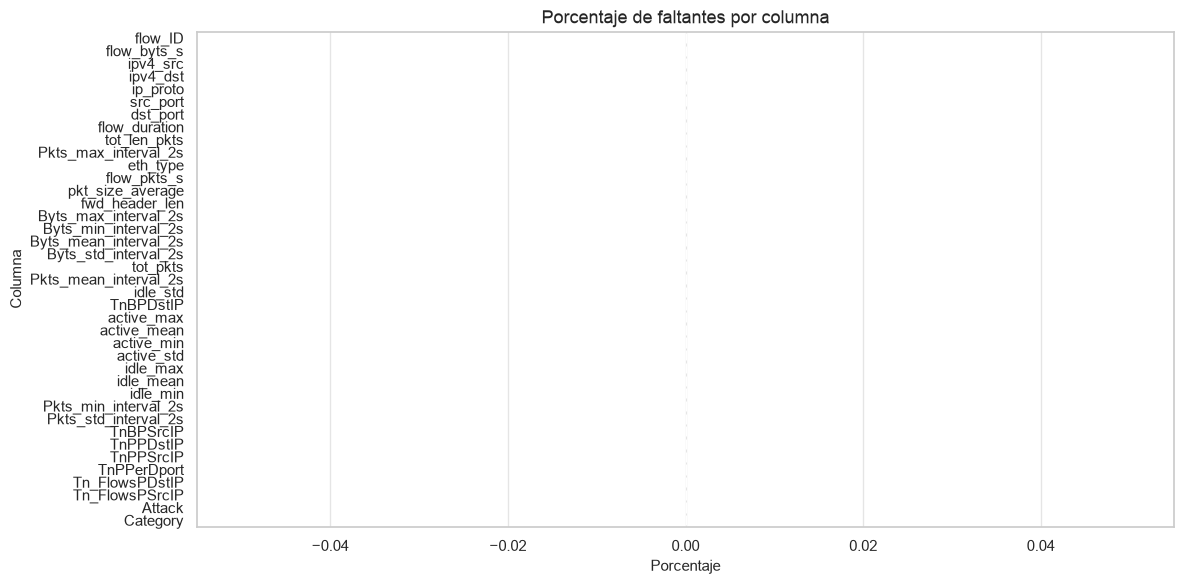

In [14]:
#! Graficamos el porcentaje de faltantes por columna, y si el dataset tiene menos de 30 columnas, graficamos un mapa de calor de los faltantes
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette="crest")
plt.title("Porcentaje de faltantes por columna")
plt.xlabel("Porcentaje")
plt.ylabel("Columna")
finalize_figure("01_faltantes_por_columna")

if len(df.columns) <= 30:
    plt.figure(figsize=(14, 8))
    sns.heatmap(df.isna(), cbar=False)
    plt.title("Mapa de faltantes")
    plt.xlabel("Columnas")
    plt.ylabel("Filas")
    finalize_figure("02_mapa_faltantes")


## Seccion 4: Analisis de la variable objetivo

Se cuantifica la distribucion de `Category`, su desbalance y la presencia de las siete clases esperadas. Este cuaderno no rebalancea el dataset.


### Exploracion de los registros por tipo de trafico dentro del dataset, mostrando conteos totales porcentaje y ordenamiento por cantidad de registros

In [23]:
#! Normalizamos la columna Category para obtener una representacion unica de todos los posibles valores de la columna sin duplicados
category_normalized = normalize_category_series(df.Category)

#? Calculamos el total de las columnas bajo el nombre de Class en lugar de Category, registrando el valor bajo la columna de Count
category_distribution = category_normalized.value_counts(dropna=False).rename_axis("Class").reset_index(name="Count")
#? Calculamos el porcentaje con la longitud total del dataframe original
category_distribution["Percentage"] = category_distribution["Count"] / len(df) * 100.0
#? Calculamos el ranking de cada clase segun su cantidad de registros, asignando un valor entero a cada clase
category_distribution["Rank"] = category_distribution["Count"].rank(method="dense", ascending=False).astype(int)

#! Calculamos en base al ranking anterior la clase con mas y menos registros
majority_class = category_distribution.iloc[0]["Class"] if not category_distribution.empty else None
minority_class = category_distribution.iloc[-1]["Class"] if not category_distribution.empty else None

#! Presentamos todos los resultados
print(f"Clase mayoritaria: {majority_class}")
print(f"Clase minoritaria: {minority_class}")
print(f"Todas las clases esperadas presentes: {set(EXPECTED_CLASSES).issubset(set(category_normalized.dropna().unique()))}")
display(category_distribution[["Class", "Count", "Percentage", "Rank"]])

Clase mayoritaria: HTTP
Clase minoritaria: NTP
Todas las clases esperadas presentes: True


,Class,Count,Percentage,Rank
0,HTTP,164974,74.458847,1
1,DNS,53551,24.16954,2
2,STREAMING,1487,0.671138,3
3,SSH,1133,0.511365,4
4,ICMP,305,0.137658,5
5,FTP,91,0.041072,6
6,NTP,23,0.010381,7


### Exploracion visual de la frecuencia de registros por clase de trafico registrada en Category

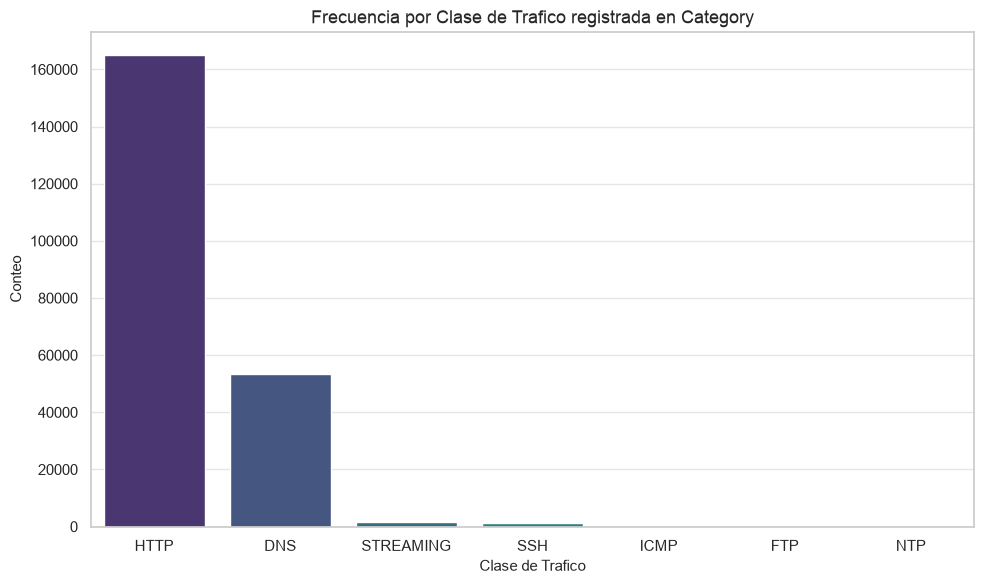

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(data=valid_category_distribution, x="Class", y="Count", palette="viridis")
plt.title("Frecuencia por Clase de Trafico registrada en Category")
plt.xlabel("Clase de Trafico")
plt.ylabel("Conteo")
finalize_figure("04_clase_frecuencia")

### Exploracion visual del porcentaje de cada clase de Category

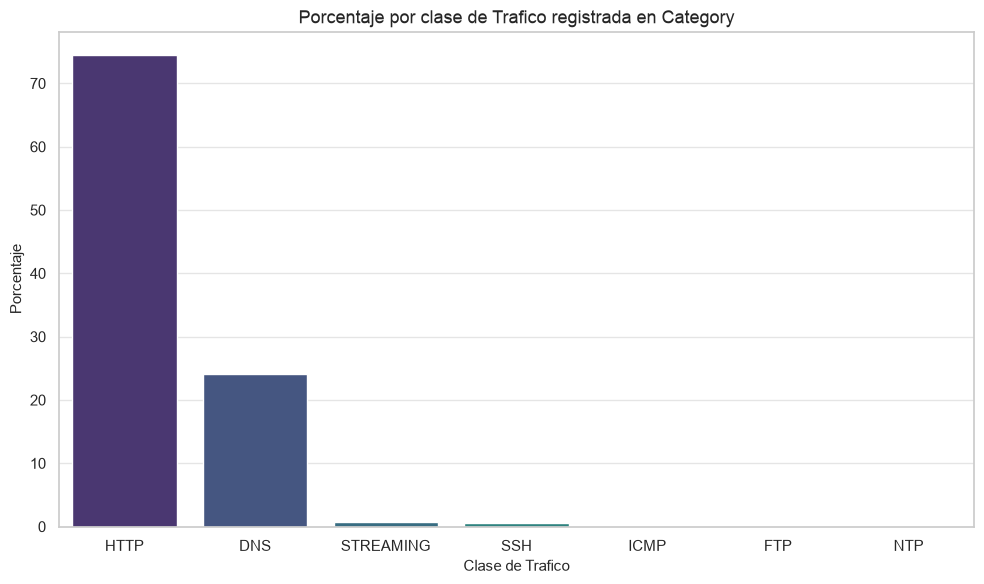

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(data=valid_category_distribution, x="Class", y="Percentage", palette="viridis")
plt.title("Porcentaje por clase de Trafico registrada en Category")
plt.xlabel("Clase de Trafico")
plt.ylabel("Porcentaje")
finalize_figure("05_clase_porcentaje")

## Seccion 5: Analisis univariado de las variables seleccionadas

Cada feature se evalua de forma individual y en relacion con `Category`. Para medidas que requieren valores validos, se usa una vista analitica normalizada sin modificar `df_raw`.


### Exploracion numerica de la cantidad de entradas del dataset utilizables para el entrenamiento del modelo en base a sus columnas claves

In [30]:
#! Generamos una copia del dataframe actual para el analisis en esta seccion
df_analysis = df.copy(deep=True)

#? Filtramos todas las columnas para aplicar una normalizacion en nombres
df_analysis.columns = [str(column).strip() for column in df_analysis.columns]

#? Aplicamos la misma normalizacion de variables categoricas para reducir posibles variaciones de nombres en la columna de analisis local
df_analysis[TARGET_COLUMN] = normalize_category_series(df_analysis[TARGET_COLUMN])

#? Para cada una de las columnas features que se usaran para el entrenamiento, se aplica una transformacion a valores numericos, para evitar analisis de variables tipo Object
for feature in FEATURE_COLUMNS:
    df_analysis[feature] = pd.to_numeric(df_analysis[feature], errors="coerce")

#! Realizamos una mascara binaria sobre la columna de target para explorar cuantas instancias de esta contiene una entrada que puede ser usada para
#! el entrenamiento del modelo
analysis_valid_mask = df_analysis[TARGET_COLUMN].isin(EXPECTED_CLASSES)
for feature, bounds in FEATURE_RULES.items():
    #? Anade a la mascara original un bitwise and sobre aquellas entradas que no son nulas
    analysis_valid_mask &= df_analysis[feature].notna()
    #? Hacemos lo mismo pero en este caso aplicamos una revision si el resultado de una operacion modulo es 0, lo que retiene valores enteros
    analysis_valid_mask &= np.isclose(df_analysis[feature] % 1, 0)
    #? Finalmente hacemos una revision sobre los rangos posibles de las variables definidas en FEATURE_RULES al inicio del notebook
    analysis_valid_mask &= df_analysis[feature].between(bounds["min"], bounds["max"])

#! Finalmente convertimos a int64 aquellas columnas seleccionadas en las columnas de entrenamiento que serian todas enteras,o deberian de serlo
df_analysis_valid = df_analysis.loc[analysis_valid_mask, TRAINING_COLUMNS].copy()
for feature in FEATURE_COLUMNS:
    df_analysis_valid[feature] = df_analysis_valid[feature].astype("Int64")

#! Presentamos resultados con la cantidad de entradas utilizables para el entrenamiento y su head
print(f"Filas validas para analisis de variables seleccionadas: {len(df_analysis_valid):,}")
display(df_analysis_valid.head())


Filas validas para analisis de variables seleccionadas: 221,564


,eth_type,ip_proto,src_port,dst_port,Category
0,2048,6,22,41410,SSH
1,2048,6,41410,22,SSH
2,2048,1,0,0,ICMP
3,2048,17,57426,1236,STREAMING
4,2048,17,48549,1234,STREAMING


### Exploracion numerica de la distribucion de valores correspondientes al tipo de paquete registrado, es decir IPv4 solo, IPv4 e IPv6, etc.

En este caso, el objetivo es determinar si el modelo aprendera sobre paquetes de tipo IPv6 adicionalmente, y si sera necesario una restructuracion del modelo de prueba

In [34]:
#! Calculamos el conteo de entradas de la columna de tipo eth_type, su porcentaje y su labela en base al mapeo definido inicialmente
eth_counts = df_analysis_valid["eth_type"].value_counts().rename_axis("eth_type").reset_index(name="count")
eth_counts["percentage"] = eth_counts["count"] / eth_counts["count"].sum() * 100.0
eth_counts["label"] = eth_counts["eth_type"].map(ETH_TYPE_LABELS).fillna("desconocido")
display(eth_counts)
#? Esta linea solo se imprime si lo unico que tenemos es IPv4
print(f"Solo IPv4 2048 presente: {set(df_analysis_valid['eth_type'].dropna().unique().tolist()) == {2048}}")





,eth_type,count,percentage,label
0,2048,221564,100.0,IPv4


Solo IPv4 2048 presente: True


### Exploracion visual de la distribucion de conteo de valores de eth_type

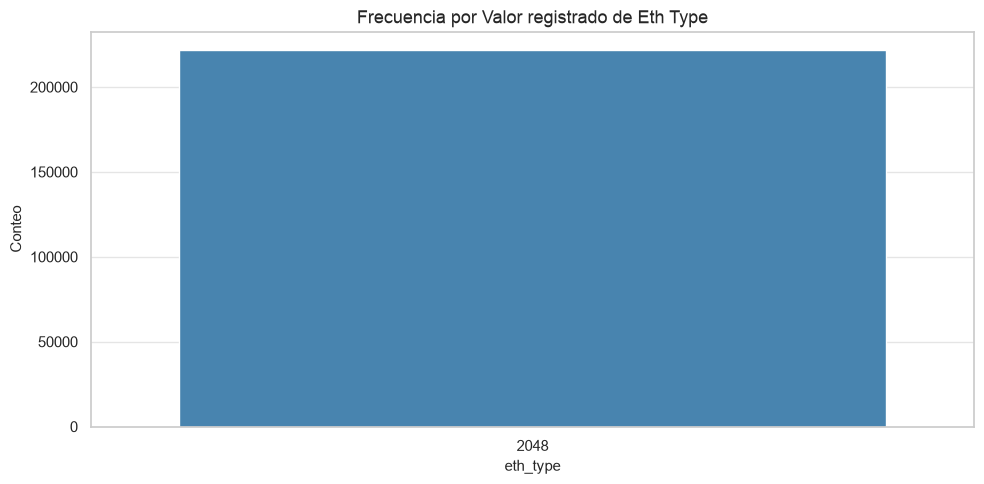

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(data=eth_counts, x="eth_type", y="count", palette="Blues_d")
plt.title("Frecuencia por Valor registrado de Eth Type")
plt.xlabel("eth_type")
plt.ylabel("Conteo")
finalize_figure("08_eth_type_frecuencia")

### Exploracion visual de la distribucion de valores normalizados de Category con respecto a Eth Type

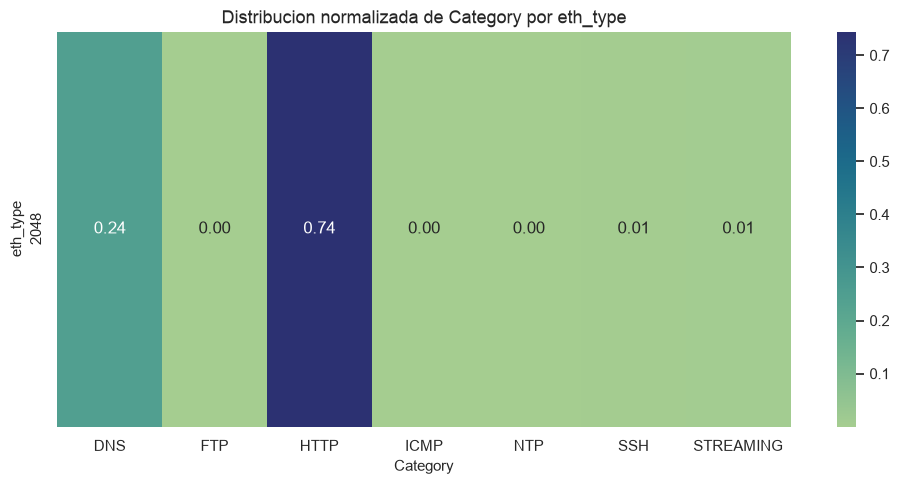

In [33]:
eth_by_class = pd.crosstab(df_analysis_valid["eth_type"], df_analysis_valid[TARGET_COLUMN], normalize="index")
plt.figure(figsize=(10, 5))
sns.heatmap(eth_by_class, annot=True, fmt=".2f", cmap="crest")
plt.title("Distribucion normalizada de Category por eth_type")
plt.xlabel("Category")
plt.ylabel("eth_type")
finalize_figure("09_eth_type_por_clase")

### Exploracion numerica de la cantidad de registros y porcentajes asociados con el Protocolo IP usado en los Flows registrados

In [36]:
#! Conteo de valores de ip_proto, correspondiente a 1 ICMP, 6 TCP y 17 UDP
proto_counts = df_analysis_valid["ip_proto"].value_counts().rename_axis("ip_proto").reset_index(name="count")
proto_counts["percentage"] = proto_counts["count"] / proto_counts["count"].sum() * 100.0
proto_counts["label"] = proto_counts["ip_proto"].map(IP_PROTO_LABELS).fillna("desconocido")
display(proto_counts)


,ip_proto,count,percentage,label
0,6,166475,75.136304,TCP
1,17,54784,24.726039,UDP
2,1,305,0.137658,ICMP


### Exploracion visual de la distribucion de frecuencia de los valores normalizados y registrados dento de ip_proto

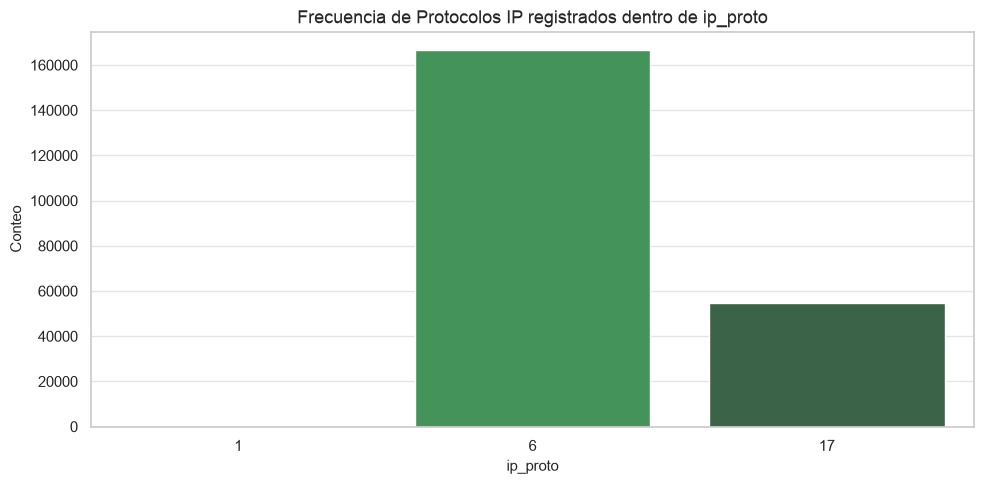

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(data=proto_counts, x="ip_proto", y="count", palette="Greens_d")
plt.title("Frecuencia de Protocolos IP registrados dentro de ip_proto")
plt.xlabel("ip_proto")
plt.ylabel("Conteo")
finalize_figure("10_ip_proto_frecuencia")

### Exploracion visual de la distribucion de valores de Protocolo IP registrado con respecto a las Clases de Trafico de Category

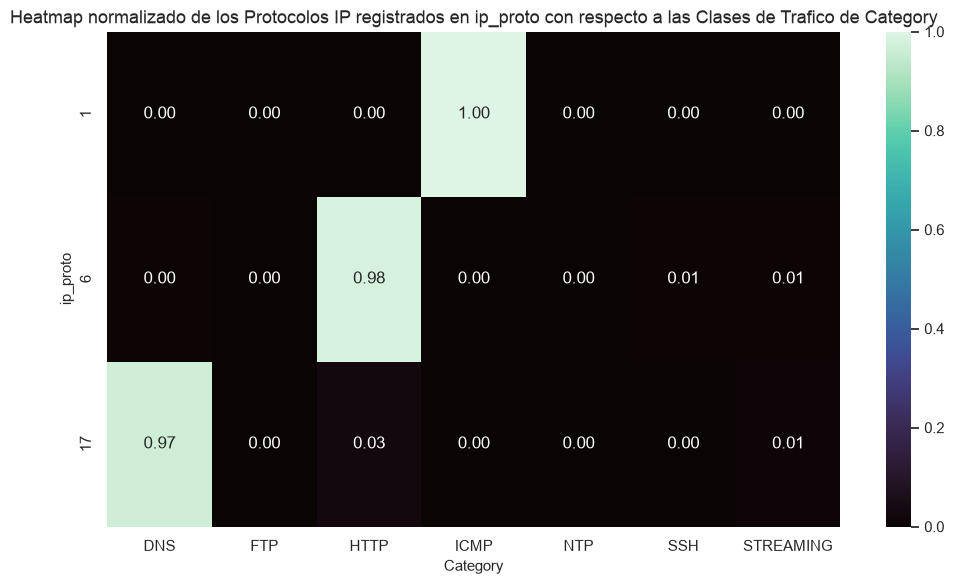

ip_proto,1,6,17
Category,,,
DNS,0.0,0.003910,0.965610
FTP,0.0,0.000547,0.000000
HTTP,0.0,0.982424,0.026011
ICMP,1.0,0.000000,0.000000
NTP,0.0,0.000000,0.000420
SSH,0.0,0.006806,0.000000
STREAMING,0.0,0.006313,0.007959


In [40]:
proto_by_class = pd.crosstab(df_analysis_valid["ip_proto"], df_analysis_valid[TARGET_COLUMN], normalize="index")
plt.figure(figsize=(10, 6))
sns.heatmap(proto_by_class, annot=True, fmt=".2f", cmap="mako")
plt.title("Heatmap normalizado de los Protocolos IP registrados en ip_proto con respecto a las Clases de Trafico de Category")
plt.xlabel("Category")
plt.ylabel("ip_proto")
finalize_figure("11_ip_proto_heatmap")

class_within_proto = pd.crosstab(df_analysis_valid[TARGET_COLUMN], df_analysis_valid["ip_proto"], normalize="columns")
display(class_within_proto)

### Exploracion visual y numerica de los diferentes tipos de puertos (src y des) registrados en el dataset

In [41]:
#! Definimos una funcion previa para la generacion de los graficos y tablas de cada seccion de analisis
def analyze_port_feature(
    frame: pd.DataFrame,
    feature: str,
) -> pd.DataFrame:
    """Analiza numerica y visualmente una variable de puerto.

    La funcion estudia una columna que representa puertos de transporte,
    normalmente ``src_port`` o ``dst_port``. El analisis incluye calidad de
    datos, estadisticas descriptivas, rangos administrativos de puertos,
    valores poco frecuentes, deteccion estadistica de valores extremos y
    distintas visualizaciones.

    Paso a paso:

    1. Comprueba que ``frame`` sea un ``DataFrame``.
    2. Comprueba que la variable exista en el conjunto de datos.
    3. Convierte la variable a formato numerico sin detener la ejecucion por
       valores no convertibles.
    4. Identifica valores nulos, no numericos, infinitos, no enteros y fuera
       del rango permitido para puertos.
    5. Conserva solamente puertos enteros validos entre 0 y 65535.
    6. Calcula estadisticas descriptivas generales.
    7. Cuenta puertos cero, privilegiados, registrados y dinamicos.
    8. Calcula cardinalidad y cantidad de valores que aparecen una sola vez.
    9. Calcula limites IQR y cantidad de valores extremos estadisticos.
    10. Muestra una tabla resumen.
    11. Genera una muestra reproducible para graficos costosos.
    12. Genera un histograma de valores originales.
    13. Genera un histograma logaritmico para puertos positivos.
    14. Genera un boxplot.
    15. Grafica los puertos mas frecuentes.
    16. Grafica la distribucion por rango administrativo.
    17. Devuelve la tabla resumen.

    Args:
        frame: Conjunto de datos que contiene la variable de puerto.
        feature: Nombre de la columna que se desea analizar.

    Returns:
        ``DataFrame`` de una fila con estadisticas de calidad, distribucion,
        cardinalidad, rangos administrativos y valores extremos.

    Raises:
        TypeError: Si ``frame`` no es un ``DataFrame`` o si ``feature`` no es
            una cadena.
        ValueError: Si ``feature`` esta vacio, si la columna no contiene
            ningun puerto valido o si la configuracion de graficos es invalida.
        KeyError: Si ``feature`` no existe en ``frame``.

    Notes:
        Los valores identificados como extremos por IQR no se eliminan. Los
        numeros de puerto son identificadores discretos y un puerto raro puede
        ser completamente valido.

        El analisis IQR se incluye como diagnostico estadistico, no como regla
        automatica de limpieza.
    """
    if not isinstance(frame, pd.DataFrame):
        raise TypeError("frame debe ser un DataFrame de Pandas.")
    if not isinstance(feature, str):
        raise TypeError("feature debe ser una cadena.")
    feature = feature.strip()
    if not feature:
        raise ValueError("feature no puede estar vacio.")
    if feature not in frame.columns:
        raise KeyError(
            f"La columna '{feature}' no existe en el DataFrame."
        )
    if TOP_N_PORTS <= 0:
        raise ValueError(
            "TOP_N_PORTS debe ser mayor que cero."
        )
    if SAMPLE_SIZE_FOR_EXPENSIVE_PLOTS <= 0:
        raise ValueError(
            "SAMPLE_SIZE_FOR_EXPENSIVE_PLOTS debe ser mayor que cero."
        )

    #! Conservamos la serie original para diagnosticar problemas de calidad.
    raw_series = frame[feature]
    numeric_series = pd.to_numeric(
        raw_series,
        errors="coerce",
    )
    numeric_array = numeric_series.to_numpy(
        dtype=float,
        na_value=np.nan,
    )
    genuine_null_mask = raw_series.isna()
    non_numeric_mask = (
        raw_series.notna()
        & numeric_series.isna()
    )
    infinite_mask = pd.Series(
        np.isinf(numeric_array),
        index=frame.index,
    )
    finite_mask = pd.Series(
        np.isfinite(numeric_array),
        index=frame.index,
    )
    non_integral_mask = pd.Series(
        False,
        index=frame.index,
    )

    #! Seleccionamos solamente valores finitos para calcular su parte decimal.
    finite_values = numeric_series.loc[finite_mask]

    #! Marcamos como valores no enteros aquellos cuya parte decimal exista luego de hacer modulo 1
    non_integral_mask.loc[finite_mask] = ~np.isclose(
        np.mod(
            finite_values.to_numpy(dtype=float),
            1.0,
        ),
        0.0,
    )
    below_range_mask = (
        finite_mask
        & numeric_series.lt(0)
    )
    above_range_mask = (
        finite_mask
        & numeric_series.gt(65535)
    )

    #! Definimos como validos solo los numeros finitos, enteros y dentro de rango.
    valid_mask = (
        finite_mask
        & ~non_integral_mask
        & ~below_range_mask
        & ~above_range_mask
    )

    #! Extraemos los puertos validos y usa un tipo entero nullable.
    valid_series = (
        numeric_series.loc[valid_mask]
        .round()
        .astype("Int64")
    )
    if valid_series.empty:
        raise ValueError(
            f"La columna '{feature}' no contiene puertos validos."
        )


    summary = describe_numeric_series(valid_series)
    summary["total_rows"] = int(len(frame))
    summary["valid_port_count"] = int(valid_series.count())
    summary["genuine_null_count"] = int(
        genuine_null_mask.sum()
    )
    summary["non_numeric_count"] = int(
        non_numeric_mask.sum()
    )
    summary["infinite_count"] = int(
        infinite_mask.sum()
    )
    summary["non_integral_count"] = int(
        non_integral_mask.sum()
    )
    summary["below_range_count"] = int(
        below_range_mask.sum()
    )
    summary["above_range_count"] = int(
        above_range_mask.sum()
    )
    summary["zero_count"] = int(
        valid_series.eq(0).sum()
    )
    summary["well_known_count"] = int(
        valid_series.between(
            0,
            1023,
            inclusive="both",
        ).sum()
    )
    summary["registered_count"] = int(
        valid_series.between(
            1024,
            49151,
            inclusive="both",
        ).sum()
    )
    summary["dynamic_count"] = int(
        valid_series.between(
            49152,
            65535,
            inclusive="both",
        ).sum()
    )
    summary["unique_count"] = int(
        valid_series.nunique(dropna=True)
    )
    value_counts = valid_series.value_counts(
        dropna=True
    )
    summary["rare_values_count"] = int(
        value_counts.eq(1).sum()
    )

    #! Realizamos los calculos de los cuartiles de los puertos registrados
    q1 = float(valid_series.quantile(0.25))
    q3 = float(valid_series.quantile(0.75))
    iqr = q3 - q1
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 1.5 * iqr
    summary["q1"] = q1
    summary["q3"] = q3
    summary["iqr"] = float(iqr)
    summary["iqr_lower"] = float(iqr_lower)
    summary["iqr_upper"] = float(iqr_upper)

    #! usamos el rango interquartlier y sus limites iferiores y superiores para marcara los puertos fuera de rango
    outlier_mask = (
        valid_series.lt(iqr_lower)
        | valid_series.gt(iqr_upper)
    )
    summary["outlier_count"] = int(
        outlier_mask.sum()
    )

    summary_table = pd.DataFrame([summary])
    print()
    display(summary_table)
    print()


    #! Extraemos solo los datos validos tomados desde los filtros iniciales para la generacion de graficos
    valid_plot_frame = pd.DataFrame(
        {
            feature: valid_series.astype(int),
        }
    )
    plot_frame = random_sample_frame(
        valid_plot_frame,
        SAMPLE_SIZE_FOR_EXPENSIVE_PLOTS,
    )

    #! Creamos un histograma sobre los puertos y su frecuencia en los datos reales
    plt.figure(figsize=(12, 5))
    sns.histplot(
        data=plot_frame,
        x=feature,
        bins=50,
        kde=False,
    )
    plt.title(f"Histograma de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frecuencia")
    finalize_figure(f"12_{feature}_hist")

    #! Conservamos solo valores positivos antes de aplicar logaritmo.
    positive_values = plot_frame.loc[
        plot_frame[feature] > 0,
        feature,
    ]

    #! Generamos el histograma logaritmico solo si existen valores positivos.
    if not positive_values.empty:
        log_values = np.log10(
            positive_values.astype(float)
        )
        plt.figure(figsize=(12, 5))
        sns.histplot(
            x=log_values,
            bins=50,
            kde=False,
        )
        plt.title(
            f"Histograma log10 de {feature} "
            "para valores positivos"
        )
        plt.xlabel(f"log10({feature})")
        plt.ylabel("Frecuencia")
        finalize_figure(f"13_{feature}_hist_log")

    print()
    #! Generamos un boxplot de los datos de la feature
    plt.figure(figsize=(12, 3))
    sns.boxplot(
        data=plot_frame,
        x=feature,
    )
    plt.title(f"Boxplot de {feature}")
    plt.xlabel(feature)
    finalize_figure(f"14_{feature}_boxplot")

    top_ports = (
        valid_series.value_counts()
        .head(TOP_N_PORTS)
        .rename_axis(feature)
        .reset_index(name="count")
    )

    top_ports[feature] = (
        top_ports[feature]
        .astype(int)
        .astype(str)
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=top_ports,
        x=feature,
        y="count",
    )
    plt.title(
        f"Puertos mas frecuentes en {feature}"
    )
    plt.xlabel(feature)
    plt.ylabel("Conteo")
    plt.xticks(rotation=45, ha="right")
    finalize_figure(f"15_{feature}_top")


    range_series = port_bucket(valid_series)


    range_distribution = (
        range_series.value_counts(
            dropna=False,
            sort=False,
        )
        .rename_axis("range")
        .reset_index(name="count")
    )

    range_distribution["range"] = (
        range_distribution["range"]
        .astype("string")
        .fillna("OUT_OF_RANGE")
    )


    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=range_distribution,
        x="range",
        y="count",
    )
    plt.title(
        f"Distribucion por rango de {feature}"
    )
    plt.xlabel("Rango")
    plt.ylabel("Conteo")
    plt.xticks(rotation=20, ha="right")
    finalize_figure(f"16_{feature}_rangos")

    # Devuelve el resumen para permitir su reutilizacion posterior.
    return summary_table

### Exploracion general de src_port

,count,min,max,mean,median,std,q1,q3,skew,kurtosis,total_rows,valid_port_count,genuine_null_count,non_numeric_count,infinite_count,non_integral_count,below_range_count,above_range_count,zero_count,well_known_count,registered_count,dynamic_count,unique_count,rare_values_count,iqr,iqr_lower,iqr_upper,outlier_count
0,221564,0.0,60999.0,23283.625174,443.0,23922.476216,443.0,46556.25,0.190069,-1.766745,221564,221564,0,0,0,0,0,0,305,111604,64691,45269,22369,6397,46113.25,-68726.875,115726.125,0


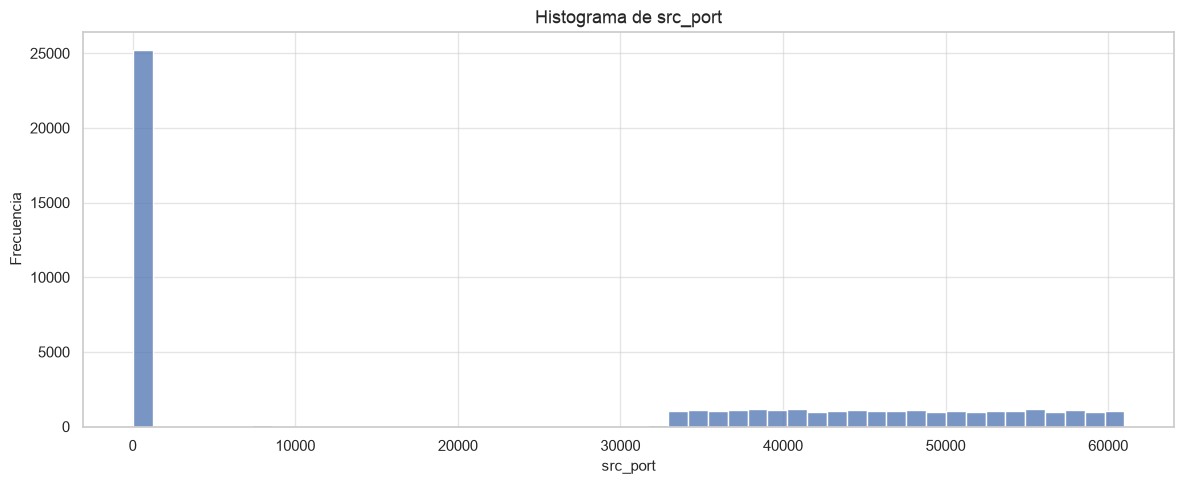

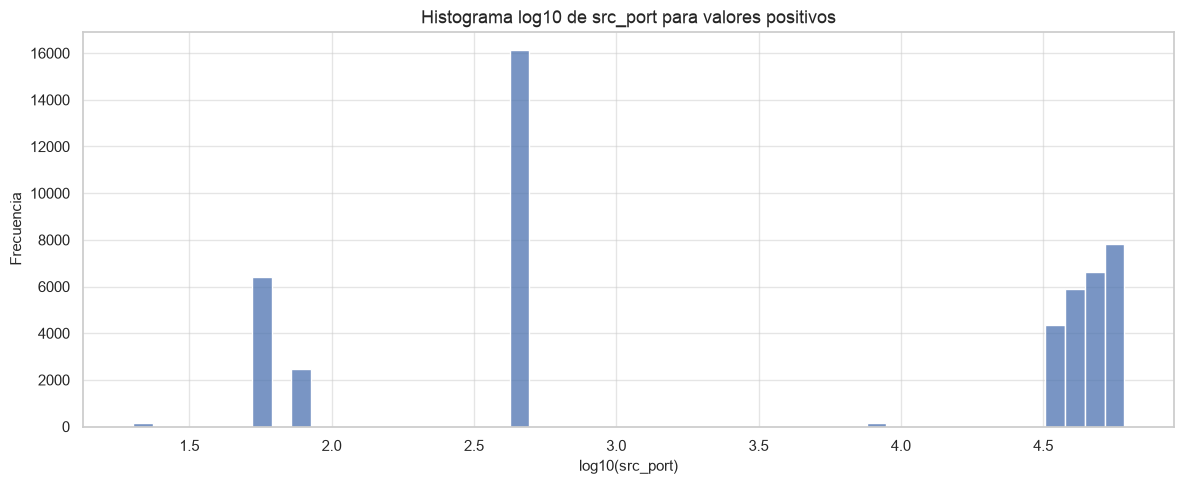

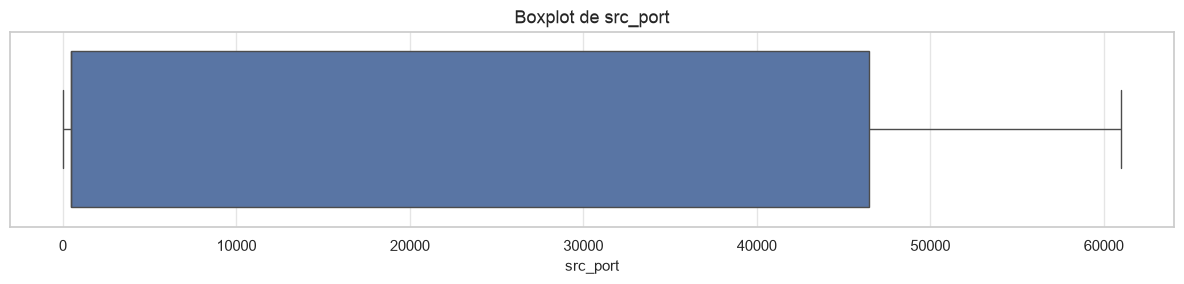

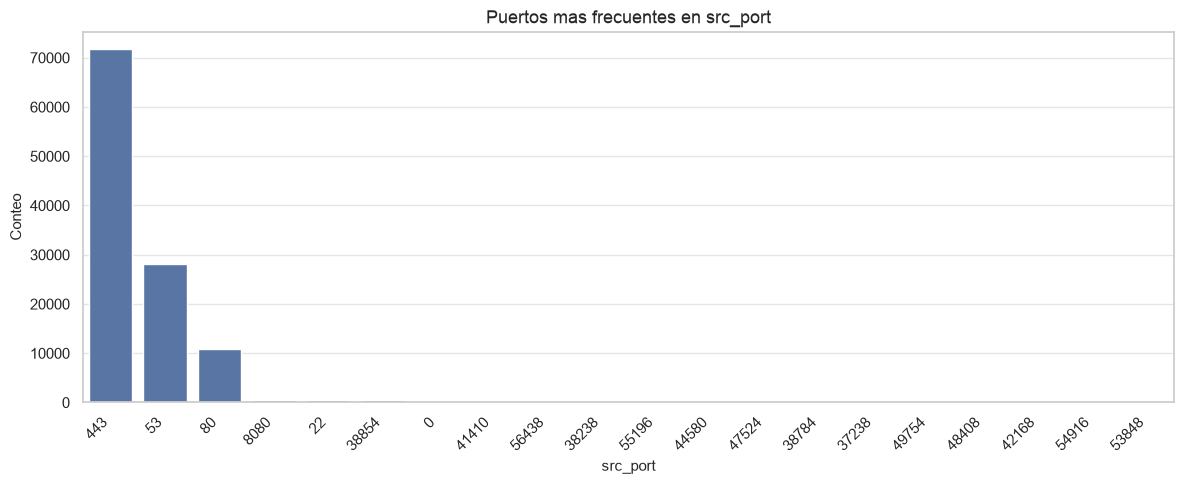

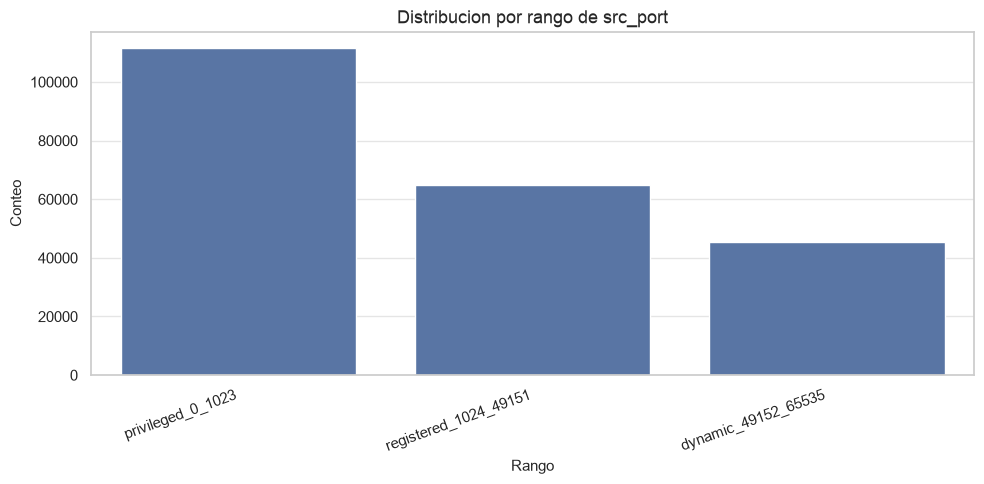

,count,min,max,mean,median,std,q1,q3,skew,kurtosis,total_rows,valid_port_count,genuine_null_count,non_numeric_count,infinite_count,non_integral_count,below_range_count,above_range_count,zero_count,well_known_count,registered_count,dynamic_count,unique_count,rare_values_count,iqr,iqr_lower,iqr_upper,outlier_count
0,221564,0.0,60999.0,23283.625174,443.0,23922.476216,443.0,46556.25,0.190069,-1.766745,221564,221564,0,0,0,0,0,0,305,111604,64691,45269,22369,6397,46113.25,-68726.875,115726.125,0


In [43]:
analyze_port_feature(df_analysis_valid, "src_port")

### Exploracion general de dst_port

,count,min,max,mean,median,std,q1,q3,skew,kurtosis,total_rows,valid_port_count,genuine_null_count,non_numeric_count,infinite_count,non_integral_count,below_range_count,above_range_count,zero_count,well_known_count,registered_count,dynamic_count,unique_count,rare_values_count,iqr,iqr_lower,iqr_upper,outlier_count
0,221564,0.0,60999.0,23806.910319,33076.0,23929.102073,443.0,46836.0,0.148177,-1.77737,221564,221564,0,0,0,0,0,0,305,108760,66595,46209,21964,5823,46393.0,-69146.5,116425.5,0


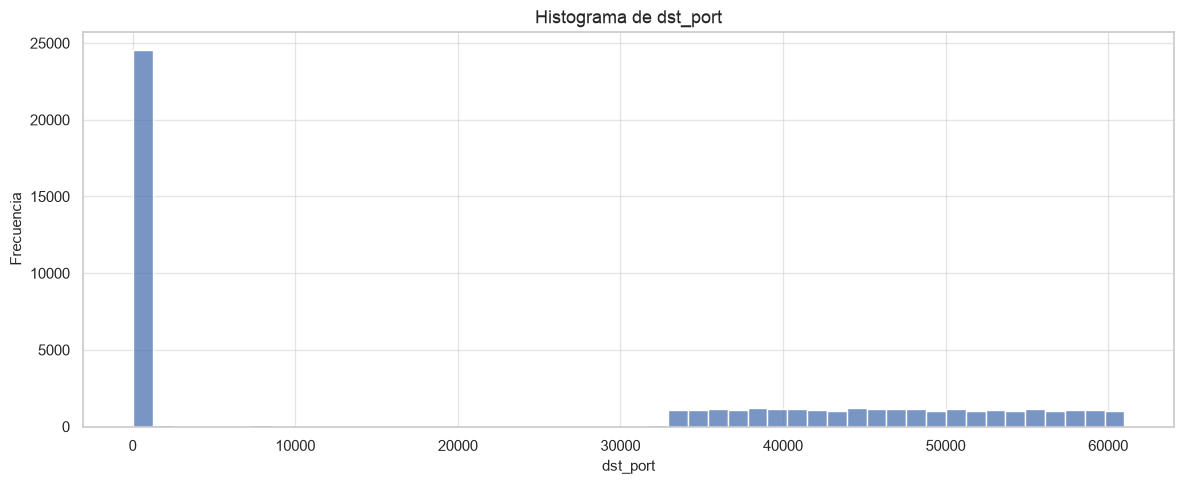

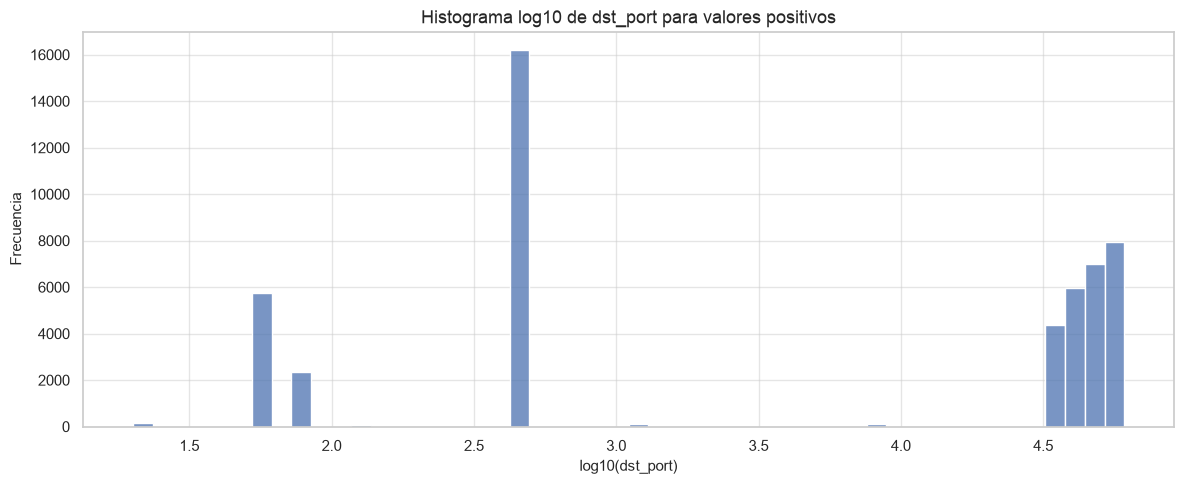

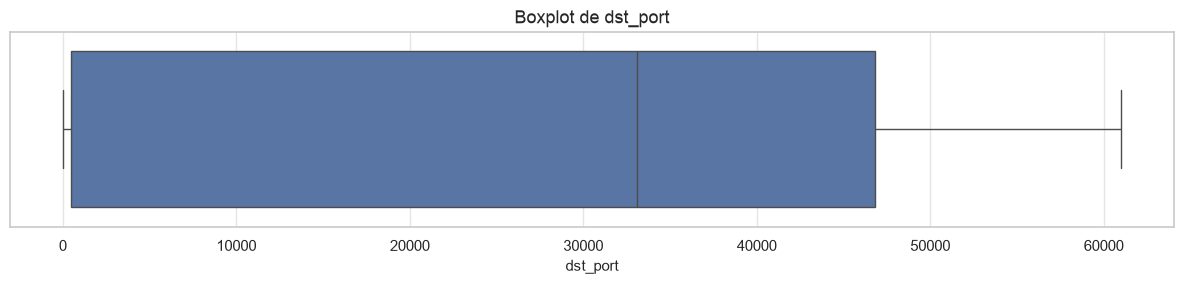

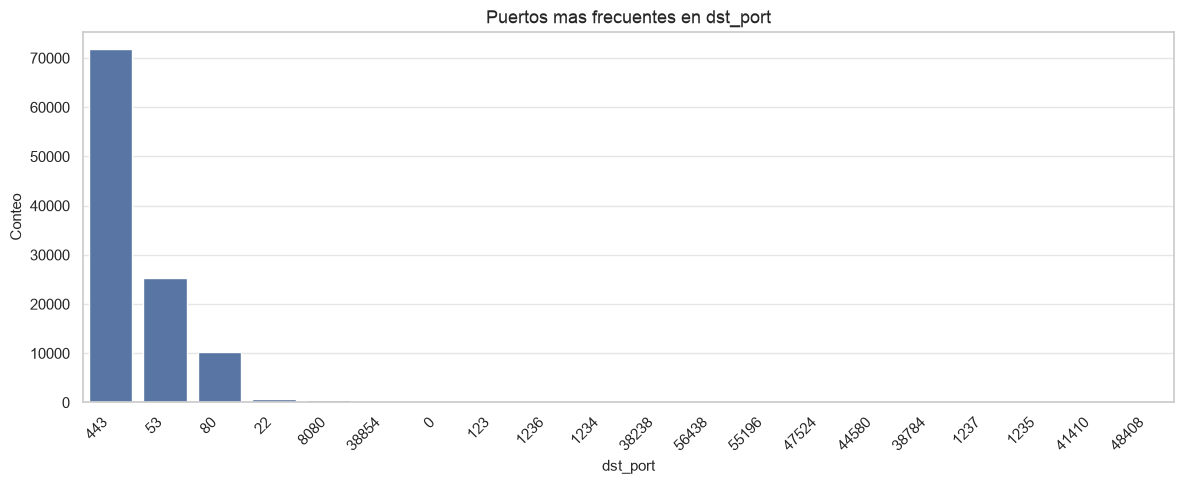

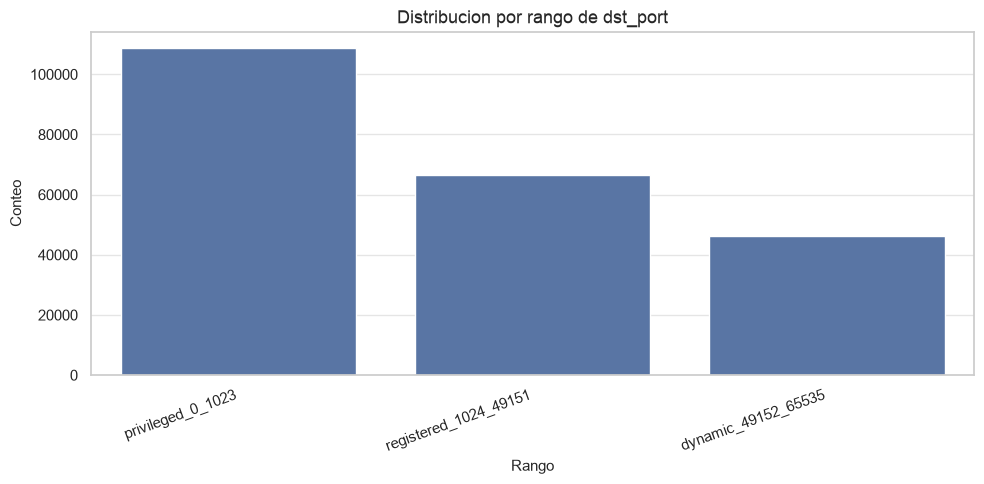

,count,min,max,mean,median,std,q1,q3,skew,kurtosis,total_rows,valid_port_count,genuine_null_count,non_numeric_count,infinite_count,non_integral_count,below_range_count,above_range_count,zero_count,well_known_count,registered_count,dynamic_count,unique_count,rare_values_count,iqr,iqr_lower,iqr_upper,outlier_count
0,221564,0.0,60999.0,23806.910319,33076.0,23929.102073,443.0,46836.0,0.148177,-1.77737,221564,221564,0,0,0,0,0,0,305,108760,66595,46209,21964,5823,46393.0,-69146.5,116425.5,0


In [44]:
analyze_port_feature(df_analysis_valid, "dst_port")

### Exploracion de puertos de destino comparado con las clases de trafico de Category

In [46]:
port_class_top = (
    df_analysis_valid.groupby(["dst_port", TARGET_COLUMN]).size().rename("count").reset_index()
    .sort_values("count", ascending=False)
)
display(port_class_top.head(30))



,dst_port,Category,count
8,443,HTTP,71787
4,53,DNS,25357
5,80,HTTP,10331
3,22,SSH,643
14,8080,STREAMING,471
6425,38854,SSH,320
0,0,ICMP,305
6,123,HTTP,263
11,1236,STREAMING,135
9,1234,STREAMING,127


### Exploracion visual de la correlacion entre los puertos de destino mas frecuentes y su Clase de Trafico

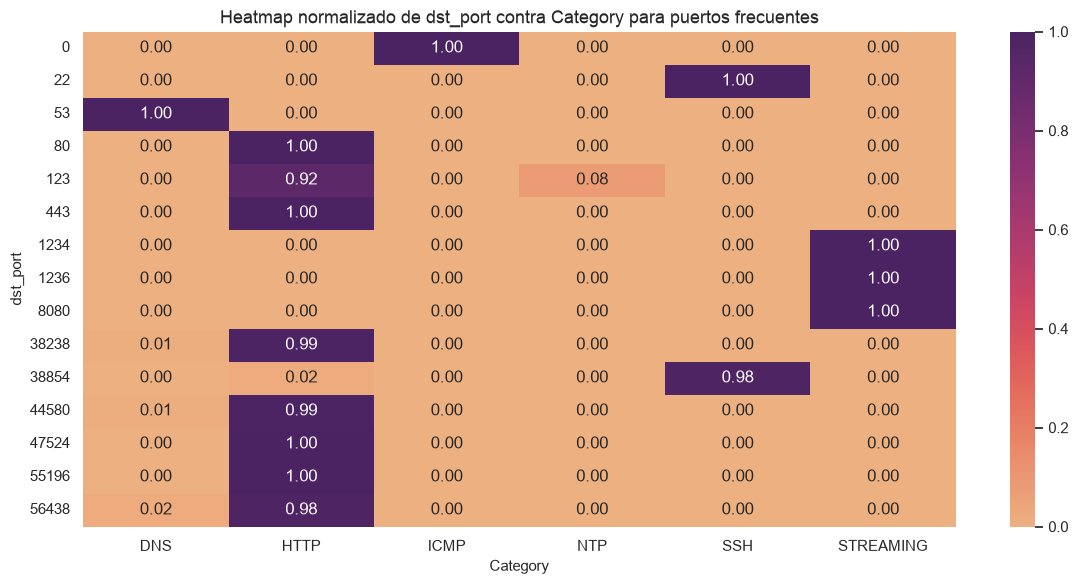

In [47]:
most_frequent_dst_ports = df_analysis_valid["dst_port"].value_counts().head(PORT_HEATMAP_TOP_N).index.tolist()
heatmap_frame = pd.crosstab(
    df_analysis_valid.loc[df_analysis_valid["dst_port"].isin(most_frequent_dst_ports), "dst_port"],
    df_analysis_valid.loc[df_analysis_valid["dst_port"].isin(most_frequent_dst_ports), TARGET_COLUMN],
    normalize="index",
)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_frame, annot=True, fmt=".2f", cmap="flare")
plt.title("Heatmap normalizado de dst_port contra Category para puertos frecuentes")
plt.xlabel("Category")
plt.ylabel("dst_port")
finalize_figure("17_dst_port_heatmap")



## Seccion 6: Correlacion y asociacion

Para esta seccion, dado que tenemos variables numericas que tienen una posible relacion medible en una correlacion, y otras que no pueden ser tomadas directamente en estos analisis, se ha optado por la separacion en dos diferentes conceptos, tomando en cuenta la correlacion como una medida cuantificable de relacion entre las variables numericas del dataset, permitiendo evaluar cuales de estas variables muestran un incremento o decremento similar.

Para esta seccion de analisis de correlacion, se usa dos diferentes acercamientos. Especificamente se usa Pearson, que permite evaluar la correlacion entre las variables tomando en cuenta una relacion lineal entre las variables, y se usa ademas Spearman para identificar correlaciones entre variables aun cuando no existe una relacion lineal entre las variables.




In [50]:
#! Extraemos las columnas del dataset en general, y aplicamos para las features una transformacion a tipo numerico entero, mientras que
#! para el resto de columnas simplemente seleccionamos las columnas que no tienen un tipo no numerico
numeric_view = df.copy()
for feature in FEATURE_COLUMNS:
    numeric_view[feature] = pd.to_numeric(numeric_view[feature], errors="coerce")

numeric_columns_for_corr = numeric_view.select_dtypes(include=[np.number]).columns.tolist()
identifier_set = set(identifier_like_columns)
numeric_columns_for_corr = [column for column in numeric_columns_for_corr if column not in identifier_set]

### Exploracion visual de la correlacion de Pearson y Spearman aplicadas a las variables numericas del dataset

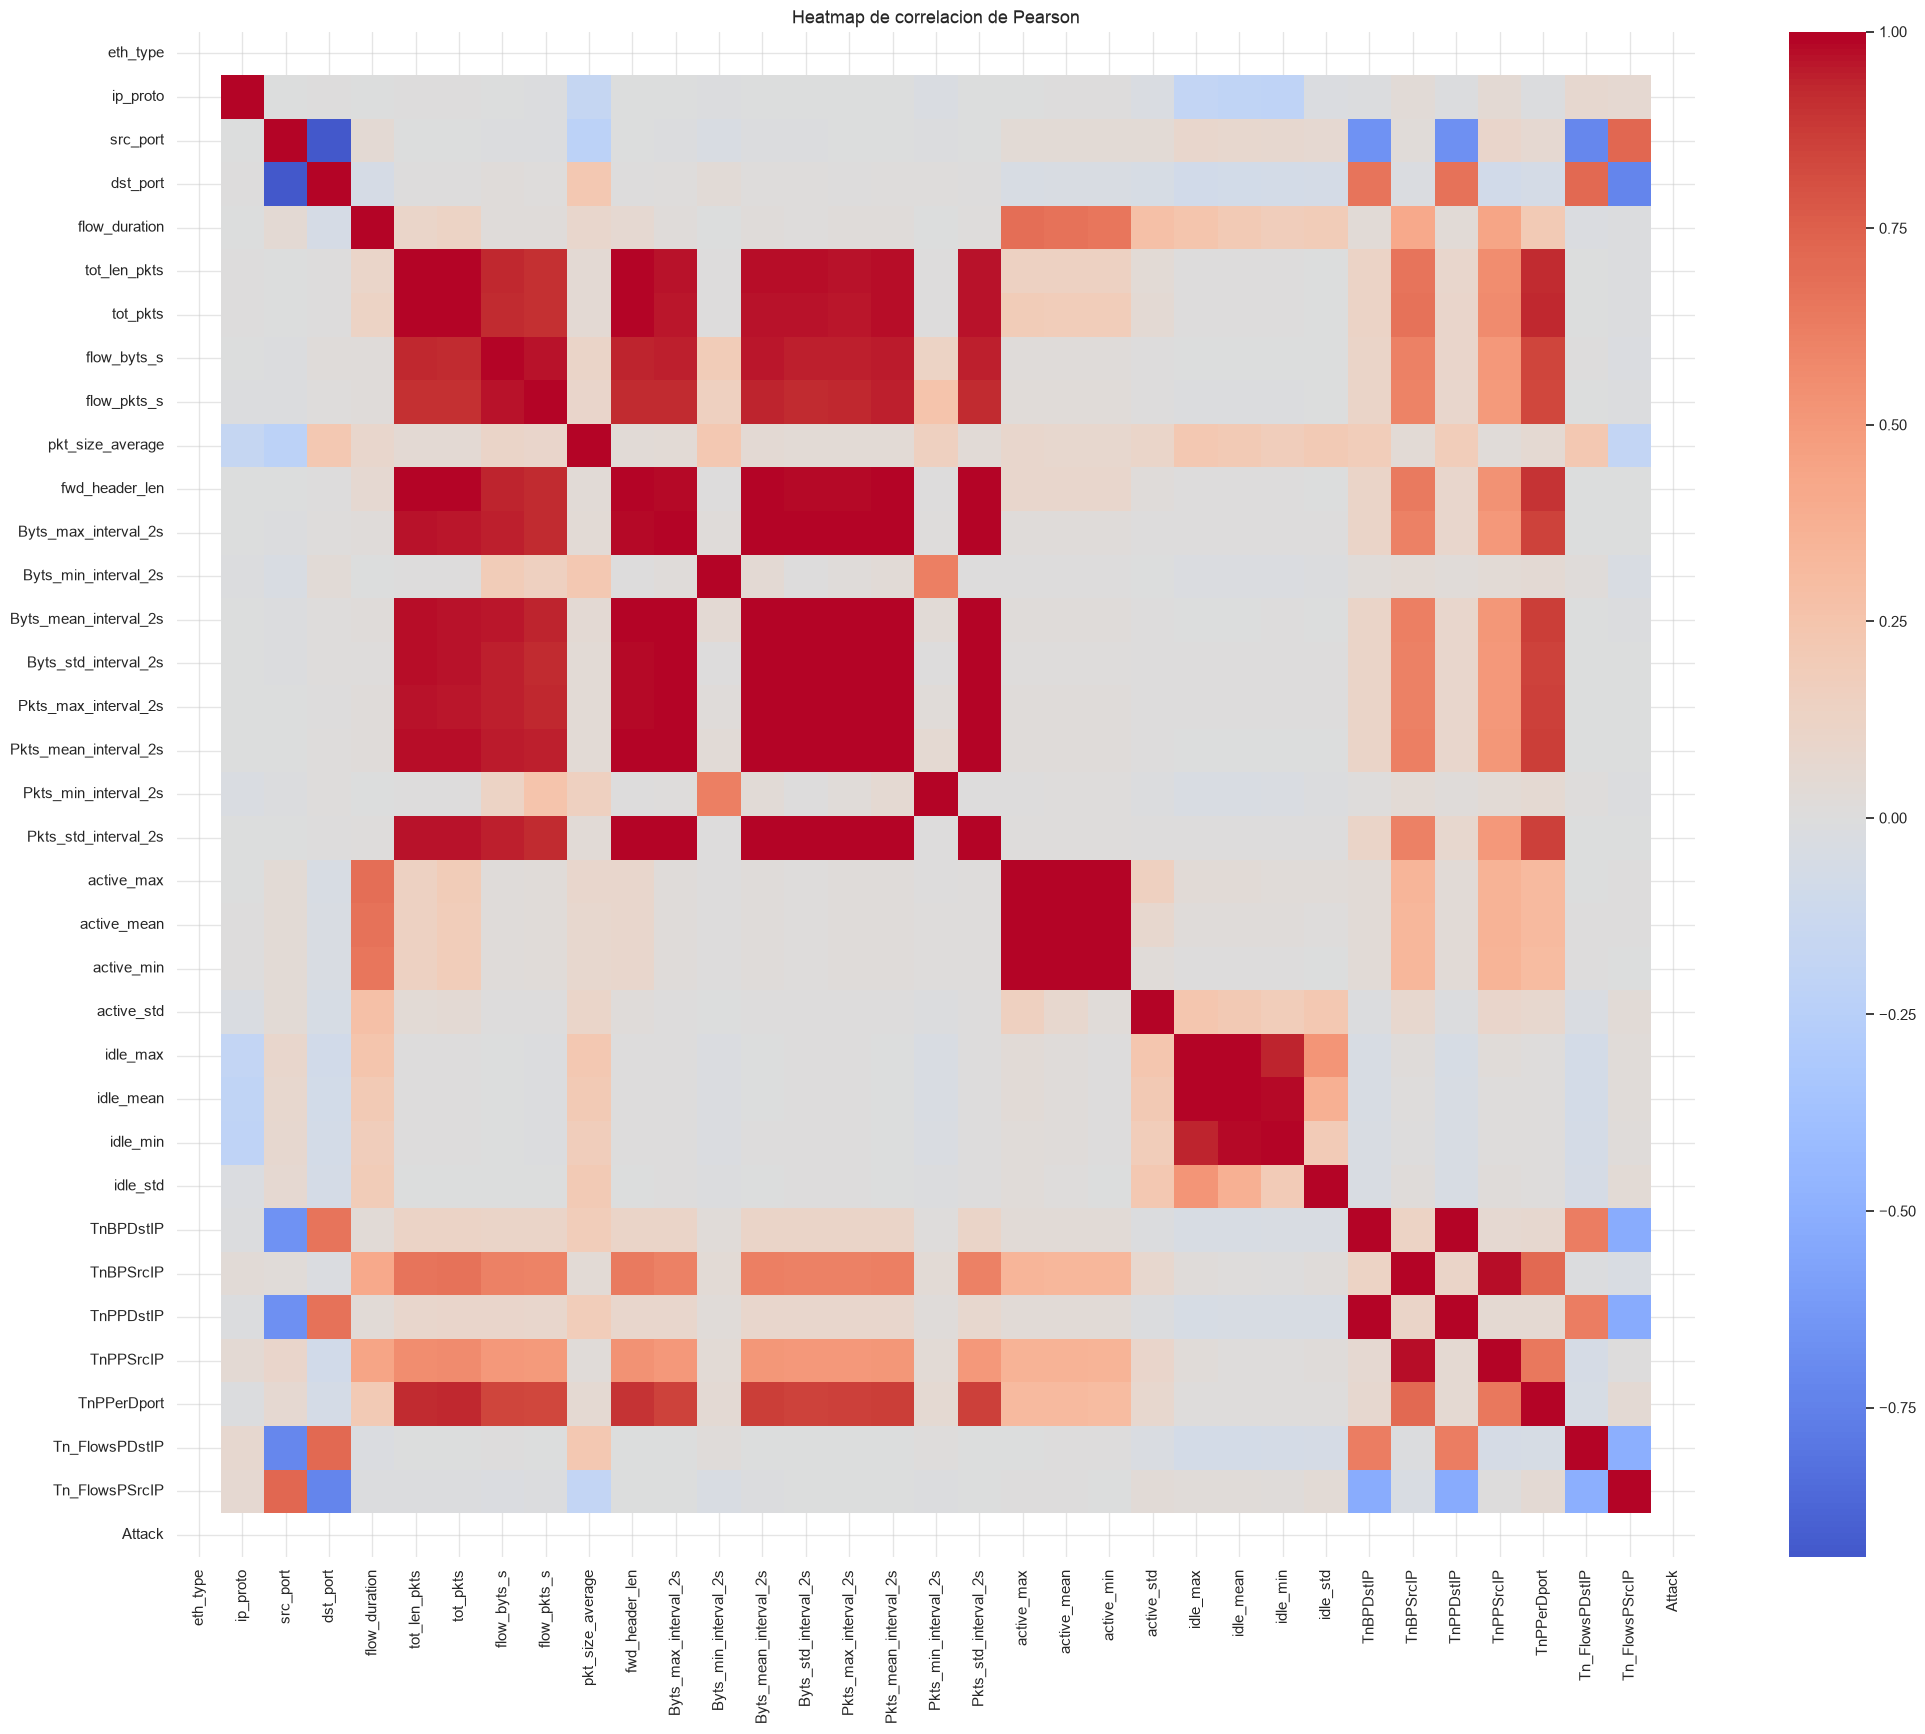

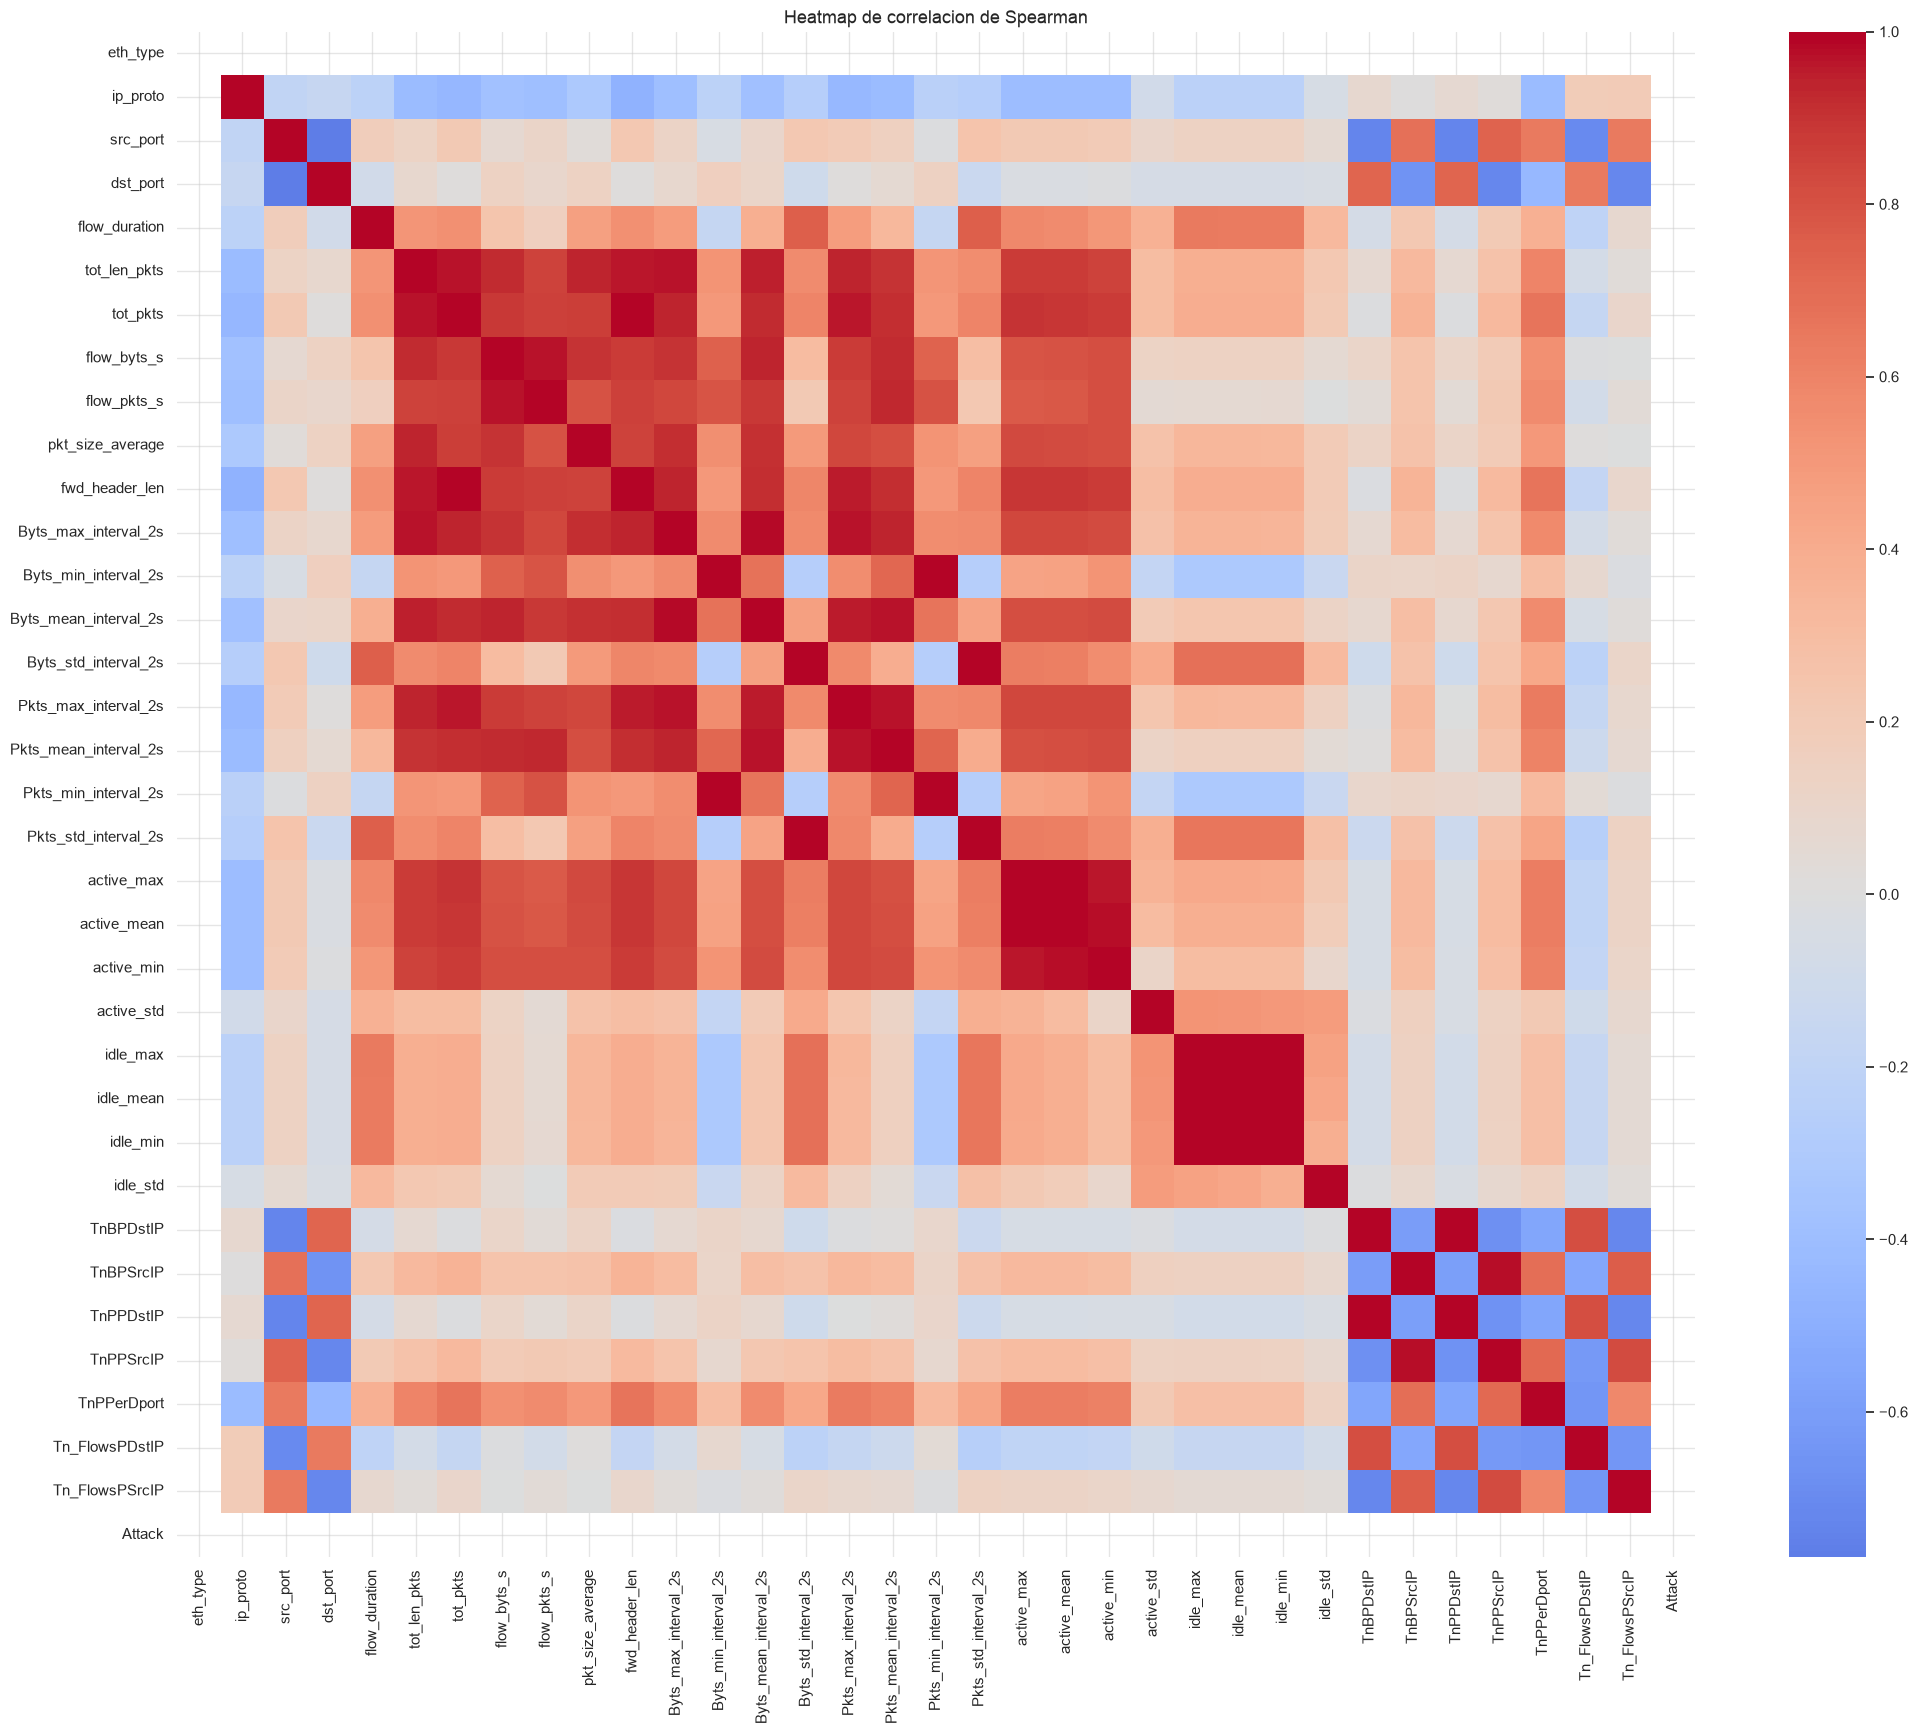

In [52]:
if numeric_columns_for_corr:
    pearson_corr = numeric_view[numeric_columns_for_corr].corr(method="pearson")
    spearman_corr = numeric_view[numeric_columns_for_corr].corr(method="spearman")

    plt.figure(figsize=(max(8, len(pearson_corr) * 0.6), max(6, len(pearson_corr) * 0.5)))
    sns.heatmap(pearson_corr, cmap="coolwarm", center=0)
    plt.title("Heatmap de correlacion de Pearson")
    finalize_figure("21_corr_pearson")

    plt.figure(figsize=(max(8, len(spearman_corr) * 0.6), max(6, len(spearman_corr) * 0.5)))
    sns.heatmap(spearman_corr, cmap="coolwarm", center=0)
    plt.title("Heatmap de correlacion de Spearman")
    finalize_figure("22_corr_spearman")


## Seccion 7: Limpieza final de los datos y exporte de datasets limpios



In [59]:
#! Definimos las columnas de salida del notebook, correspondientes a las features y el target solo
OUTPUT_COLUMNS = FEATURE_COLUMNS + [TARGET_COLUMN]

#? Verificamos que todas las columnas existan en el dataframe
missing_columns = [
    column
    for column in OUTPUT_COLUMNS
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"Faltan columnas obligatorias: {missing_columns}"
    )

# Crea un nuevo DataFrame con las variables del modelo y la categoria objetivo.
df_clean = df[OUTPUT_COLUMNS].copy()
df_clean[TARGET_COLUMN] = normalize_category_series(
    df_clean[TARGET_COLUMN]
)
_, numeric_features, feature_details = feature_validity_report(df_clean)
invalid_feature_rows = pd.Series(False, index=df_clean.index)

for feature in FEATURE_COLUMNS:
    invalid_feature_rows |= feature_details[feature]["invalid_mask"]

if invalid_feature_rows.any():
    invalid_count = int(invalid_feature_rows.sum())

    raise ValueError(
        f"Se encontraron {invalid_count} filas con valores invalidos "
        "en las variables seleccionadas."
    )


for feature in FEATURE_COLUMNS:
    df_clean[feature] = numeric_features[feature].astype("Int64")

# Conserva el orden definido en FEATURE_COLUMNS y coloca el target al final.
df_clean = df_clean[OUTPUT_COLUMNS].reset_index(drop=True)

# Construye la ruta final de exportacion.
training_output_path = OUTPUT_DIR / TRAINING_OUTPUT_FILENAME

# Crea el directorio de salida cuando no exista.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Guarda el dataset reducido sin incluir el indice de Pandas.
df_clean.to_csv(
    training_output_path,
    index=False,
    encoding="utf-8",
)

# Muestra una vista rapida del resultado.
display(df_clean.head())

print(f"Dataset limpio guardado en: {training_output_path}")
print(f"Dimensiones finales: {df_clean.shape}")
print(f"Columnas finales: {df_clean.columns.tolist()}")
print(f"Tipos finales:\n{df_clean.dtypes}")

,eth_type,ip_proto,src_port,dst_port,Category
0,2048,6,22,41410,SSH
1,2048,6,41410,22,SSH
2,2048,1,0,0,ICMP
3,2048,17,57426,1236,STREAMING
4,2048,17,48549,1234,STREAMING


Dataset limpio guardado en: ../../../res/data/processed/SDNFlow_Training_Sample_Dataset.csv
Dimensiones finales: (221564, 5)
Columnas finales: ['eth_type', 'ip_proto', 'src_port', 'dst_port', 'Category']
Tipos finales:
eth_type     Int64
ip_proto     Int64
src_port     Int64
dst_port     Int64
Category    string
dtype: object
